# Tarea 3 — Modelamiento Ecológico Cross-Dataset

**IELE756 — Preparación y Análisis de Datos**

**Integrantes:** Gaspar Lämmel + Fernando Rodríguez  
**Comunas asignadas:** Las Condes (13114) + Curacaví (13503)  
**Fecha:** 03/05/2026

## Objetivo

El objetivo de esta tarea es construir modelos de regresión ecológica que vinculen características demográficas y socioeconómicas de las comunas obtenidas del Censo 2024 con indicadores de salud pública de las notificaciones ENO y egresos hospitalarios GRD.

El análisis es ecológico porque la unidad de observación es la comuna, no la persona. Esto significa que todos los coeficientes estimados describen asociaciones entre comunas con distintas composiciones agregadas, y no pueden interpretarse como efectos individuales.

El notebook está organizado en 7 partes:

1. **Parte 1:** Construcción de la tabla analítica unificando los CSV de todos los equipos del curso
2. **Parte 2:** Análisis exploratorio cross-dataset: correlaciones y scatter plots
3. **Parte 3:** Modelos de conteo Poisson y Negative Binomial para ENO y GRD
4. **Parte 4:** Regresión OLS para outcome continuo GRD
5. **Parte 5:** Discusión de la falacia ecológica e interpretación sustantiva
6. **Parte 6:** Visualización espacial de predicciones y residuos del modelo
7. **Parte 7:** Síntesis integrada y exportación final de todos los resultados

---
## Parte 1 — Construcción de la tabla analítica

En esta primera parte construimos la tabla analítica principal del análisis. El punto de partida son los archivos CSV que cada equipo del curso subió al pool compartido en el Quiz 1: un archivo `census_teamNN.csv`, un `eno_teamNN.csv` y un `grd_teamNN.csv` por equipo.

El código busca todos estos archivos de forma recursiva en las carpetas configuradas, los carga, los normaliza (por si algún equipo usó nombres de columna ligeramente distintos o encodings diferentes), resuelve duplicados y finalmente hace un merge de las tres fuentes en una sola tabla comunal.

Al final de esta parte tenemos una tabla donde cada fila es una comuna de la Región Metropolitana y cada columna es un indicador censal o sanitario. Esta tabla es el insumo de todo el análisis posterior.

**Variables derivadas que se crean en esta parte:**
- `pct_foreign`: porcentaje de población extranjera
- `log_pop_total`: logaritmo natural de la población (para usar como offset en modelos de conteo)
- `emp_rate_combined`: tasa de empleo ponderada entre chilenos y extranjeros
- `pct_unemployed`: porcentaje de desempleo aproximado
- `schooling_gap`: diferencia en años de escolaridad entre chilenos y extranjeros
- `mean_schooling_total`: escolaridad promedio ponderada
- `median_age_gap`: diferencia de edad mediana entre extranjeros y chilenos
- `eno_rate_per_10k` y `grd_rate_per_10k`: tasas sanitarias por 10.000 habitantes

In [16]:
# ============================================================
# PARTE 1: CONFIGURACIÓN GENERAL Y TABLA ANALÍTICA
# TAREA 3 — CROSS-DATASET ECOLOGICAL MODELING
# ============================================================

# ------------------------------------------------------------
# 1.1 Instalación de librerías necesarias
# ------------------------------------------------------------

%pip install -q geopandas statsmodels openpyxl mapclassify

# ------------------------------------------------------------
# 1.2 Importación de librerías
# ------------------------------------------------------------

from google.colab import drive
drive.mount("/content/drive")

import os
import re
import glob
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd

import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# ------------------------------------------------------------
# 1.3 Rutas principales
# ------------------------------------------------------------

RUTA_BASE_FERN = Path("/content/drive/MyDrive/ColabNotebooks")

RUTA_GRUPOS_FERN = RUTA_BASE_FERN / "grupos"
RUTA_SHARED_FERN = RUTA_BASE_FERN / "shared"
RUTA_OUTPUT_FERN = RUTA_BASE_FERN / "output"

RUTA_COMUNAS_FERN = RUTA_BASE_FERN / "COMUNAS"
RUTA_COMUNAS_SHP_FERN = RUTA_COMUNAS_FERN / "COMUNAS_v1.shp"

RUTA_OUTPUT_FERN.mkdir(parents=True, exist_ok=True)
RUTA_SHARED_FERN.mkdir(parents=True, exist_ok=True)

RUTA_CENSUS_MASTER_FERN = RUTA_OUTPUT_FERN / "tarea3_census_master.csv"
RUTA_ENO_MASTER_FERN = RUTA_OUTPUT_FERN / "tarea3_eno_master.csv"
RUTA_GRD_MASTER_FERN = RUTA_OUTPUT_FERN / "tarea3_grd_master.csv"
RUTA_ANALYTICAL_FERN = RUTA_OUTPUT_FERN / "tarea3_analytical_table.csv"

TEAM_FERN = 17

CODIGOS_COMUNAS_FERN = [13114, 13503]
NOMBRES_COMUNAS_FERN = ["LAS CONDES", "CURACAVÍ"]

print("Rutas configuradas:")
print("RUTA_BASE_FERN:", RUTA_BASE_FERN)
print("RUTA_GRUPOS_FERN:", RUTA_GRUPOS_FERN)
print("RUTA_OUTPUT_FERN:", RUTA_OUTPUT_FERN)
print("RUTA_COMUNAS_SHP_FERN:", RUTA_COMUNAS_SHP_FERN)

# ------------------------------------------------------------
# 1.4 Funciones auxiliares
# ------------------------------------------------------------

def mostrar_titulo_fern(texto_fern):
    display(Markdown(texto_fern))


def normalizar_nombre_columna_fern(columna_fern):
    columna_fern = str(columna_fern).strip().lower()
    columna_fern = columna_fern.replace("á", "a").replace("é", "e").replace("í", "i")
    columna_fern = columna_fern.replace("ó", "o").replace("ú", "u").replace("ñ", "n")
    columna_fern = re.sub(r"[^a-z0-9]+", "_", columna_fern)
    columna_fern = re.sub(r"_+", "_", columna_fern).strip("_")
    return columna_fern


def normalizar_columnas_fern(df_fern):
    df_fern = df_fern.copy()
    df_fern.columns = [normalizar_nombre_columna_fern(c) for c in df_fern.columns]
    return df_fern


def leer_csv_seguro_fern(ruta_fern):
    intentos_fern = [
        {"sep": ",", "encoding": "utf-8"},
        {"sep": ";", "encoding": "utf-8"},
        {"sep": ",", "encoding": "latin1"},
        {"sep": ";", "encoding": "latin1"},
        {"sep": None, "encoding": "utf-8", "engine": "python"},
        {"sep": None, "encoding": "latin1", "engine": "python"},
    ]

    ultimo_error_fern = None

    for kwargs_fern in intentos_fern:
        try:
            df_fern = pd.read_csv(ruta_fern, **kwargs_fern)
            df_fern = normalizar_columnas_fern(df_fern)

            if df_fern.shape[1] >= 2:
                return df_fern

        except Exception as error_fern:
            ultimo_error_fern = error_fern

    raise ValueError(f"No se pudo leer el CSV: {ruta_fern}. Último error: {ultimo_error_fern}")


def detectar_familia_archivo_fern(ruta_fern):
    nombre_fern = Path(ruta_fern).name.lower()

    if nombre_fern.startswith("census") or "census_team" in nombre_fern:
        return "census"

    if nombre_fern.startswith("eno") or "eno_team" in nombre_fern:
        return "eno"

    if nombre_fern.startswith("grd") or "grd_team" in nombre_fern:
        return "grd"

    return "otro"


def extraer_team_desde_ruta_fern(ruta_fern):
    ruta_txt_fern = str(ruta_fern).lower()

    patrones_fern = [
        r"team[_\s\-]*0*([0-9]+)",
        r"/0*([0-9]{1,2})/",
        r"\\0*([0-9]{1,2})\\"
    ]

    for patron_fern in patrones_fern:
        match_fern = re.search(patron_fern, ruta_txt_fern)
        if match_fern:
            return int(match_fern.group(1))

    return np.nan


def asegurar_codigo_comuna_fern(df_fern):
    df_fern = df_fern.copy()

    if "codigo_comuna" not in df_fern.columns:
        candidatos_fern = [
            c for c in df_fern.columns
            if c in ["cod_comuna", "codigo", "cut_com", "cut_comuna", "comuna_codigo"]
            or ("codigo" in c and "comuna" in c)
            or ("cod" in c and "comuna" in c)
            or ("cut" in c and "comuna" in c)
        ]

        if len(candidatos_fern) == 0:
            raise ValueError("No se encontró columna equivalente a codigo_comuna.")

        df_fern = df_fern.rename(columns={candidatos_fern[0]: "codigo_comuna"})

    df_fern["codigo_comuna"] = pd.to_numeric(df_fern["codigo_comuna"], errors="coerce")
    df_fern = df_fern.dropna(subset=["codigo_comuna"]).copy()
    df_fern["codigo_comuna"] = df_fern["codigo_comuna"].astype(int)

    return df_fern


def asegurar_nombre_comuna_fern(df_fern):
    df_fern = df_fern.copy()

    if "nombre_comuna" not in df_fern.columns:
        candidatos_fern = [
            c for c in df_fern.columns
            if c in ["comuna", "nom_comuna", "nombre", "nombre_com", "nom_com"]
            or ("nombre" in c and "comuna" in c)
        ]

        if len(candidatos_fern) > 0:
            df_fern = df_fern.rename(columns={candidatos_fern[0]: "nombre_comuna"})

    if "nombre_comuna" in df_fern.columns:
        df_fern["nombre_comuna"] = (
            df_fern["nombre_comuna"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

    return df_fern


def convertir_numericas_posibles_fern(df_fern):
    df_fern = df_fern.copy()

    columnas_texto_fern = [
        "nombre_comuna",
        "eno_top3_diseases",
        "grd_top3_chapters",
        "source_file_fern",
        "source_path_fern"
    ]

    for col_fern in df_fern.columns:
        if col_fern in columnas_texto_fern:
            continue

        if df_fern[col_fern].dtype == "object":
            serie_fern = (
                df_fern[col_fern]
                .astype(str)
                .str.replace("%", "", regex=False)
                .str.replace(",", ".", regex=False)
                .str.strip()
            )

            convertida_fern = pd.to_numeric(serie_fern, errors="coerce")

            if convertida_fern.notna().mean() >= 0.70:
                df_fern[col_fern] = convertida_fern

    return df_fern


def primera_moda_fern(serie_fern):
    serie_fern = serie_fern.dropna()

    if len(serie_fern) == 0:
        return np.nan

    moda_fern = serie_fern.mode()

    if len(moda_fern) > 0:
        return moda_fern.iloc[0]

    return serie_fern.iloc[0]


def unir_textos_unicos_fern(serie_fern):
    valores_fern = (
        serie_fern
        .dropna()
        .astype(str)
        .str.strip()
    )

    valores_fern = [
        v for v in valores_fern
        if v != "" and v.lower() != "nan"
    ]

    if len(valores_fern) == 0:
        return np.nan

    return " | ".join(sorted(set(valores_fern)))


def descomprimir_zips_fern(carpetas_fern):
    zips_fern = []

    for carpeta_fern in carpetas_fern:
        if carpeta_fern.exists():
            zips_fern.extend(glob.glob(str(carpeta_fern / "**/*.zip"), recursive=True))

    zips_fern = sorted(set(zips_fern))

    for zip_fern in zips_fern:
        zip_fern = Path(zip_fern)
        destino_fern = zip_fern.parent / f"{zip_fern.stem}_extraido_fern"
        destino_fern.mkdir(parents=True, exist_ok=True)

        try:
            with zipfile.ZipFile(zip_fern, "r") as zip_ref_fern:
                zip_ref_fern.extractall(destino_fern)

            print(f"ZIP extraído: {zip_fern.name}")

        except Exception as error_fern:
            print(f"No se pudo extraer {zip_fern.name}: {error_fern}")


def construir_master_familia_fern(df_archivos_fern, familia_fern):
    rutas_fern = df_archivos_fern.loc[
        df_archivos_fern["familia"] == familia_fern,
        "ruta"
    ].tolist()

    dataframes_fern = []
    errores_fern = []

    for ruta_fern in rutas_fern:
        try:
            df_fern = leer_csv_seguro_fern(ruta_fern)
            df_fern = asegurar_codigo_comuna_fern(df_fern)
            df_fern = asegurar_nombre_comuna_fern(df_fern)
            df_fern = convertir_numericas_posibles_fern(df_fern)

            df_fern[f"{familia_fern}_source_file_fern"] = Path(ruta_fern).name
            df_fern[f"{familia_fern}_source_team_fern"] = extraer_team_desde_ruta_fern(ruta_fern)
            df_fern[f"{familia_fern}_source_path_fern"] = str(ruta_fern)

            dataframes_fern.append(df_fern)

        except Exception as error_fern:
            errores_fern.append({
                "familia": familia_fern,
                "ruta": str(ruta_fern),
                "error": str(error_fern)
            })

    if len(dataframes_fern) == 0:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame(errores_fern)

    raw_fern = pd.concat(dataframes_fern, ignore_index=True, sort=False)

    duplicados_fern = (
        raw_fern[raw_fern.duplicated("codigo_comuna", keep=False)]
        .sort_values("codigo_comuna")
        .copy()
    )

    agg_fern = {}

    for col_fern in raw_fern.columns:
        if col_fern == "codigo_comuna":
            continue

        if "source_file" in col_fern or "source_path" in col_fern or "source_team" in col_fern:
            agg_fern[col_fern] = unir_textos_unicos_fern

        elif pd.api.types.is_numeric_dtype(raw_fern[col_fern]):
            agg_fern[col_fern] = "median"

        else:
            agg_fern[col_fern] = primera_moda_fern

    master_fern = (
        raw_fern
        .groupby("codigo_comuna", as_index=False)
        .agg(agg_fern)
    )

    return master_fern, raw_fern, duplicados_fern, pd.DataFrame(errores_fern)


# ------------------------------------------------------------
# 1.5 Búsqueda recursiva de archivos del pool
# ------------------------------------------------------------

mostrar_titulo_fern("## Parte 1 — Construcción de la tabla analítica")

CARPETAS_POOL_FERN = [
    RUTA_GRUPOS_FERN,
    RUTA_SHARED_FERN,
    RUTA_OUTPUT_FERN
]

descomprimir_zips_fern(CARPETAS_POOL_FERN)

archivos_csv_fern = []

for carpeta_fern in CARPETAS_POOL_FERN:
    if carpeta_fern.exists():
        archivos_csv_fern.extend(glob.glob(str(carpeta_fern / "**/*.csv"), recursive=True))

archivos_csv_fern = sorted(set(archivos_csv_fern))

df_archivos_fern = pd.DataFrame({
    "ruta": archivos_csv_fern,
    "archivo": [Path(x).name for x in archivos_csv_fern],
    "familia": [detectar_familia_archivo_fern(x) for x in archivos_csv_fern],
    "team": [extraer_team_desde_ruta_fern(x) for x in archivos_csv_fern]
})

df_archivos_fern = df_archivos_fern[df_archivos_fern["familia"].isin(["census", "eno", "grd"])].copy()

mostrar_titulo_fern("### Archivos detectados")
display(df_archivos_fern.sort_values(["familia", "team", "archivo"]))

mostrar_titulo_fern("### Resumen de archivos detectados")
display(
    df_archivos_fern
    .groupby("familia", as_index=False)
    .agg(
        n_archivos=("archivo", "count"),
        n_teams=("team", "nunique")
    )
)

if len(df_archivos_fern) == 0:
    raise FileNotFoundError(
        "No se detectaron CSV tipo census_team, eno_team o grd_team. "
        "Revisa que estén dentro de ColabNotebooks/grupos, ColabNotebooks/shared o ColabNotebooks/output."
    )

# ------------------------------------------------------------
# 1.6 Construcción de master tables
# ------------------------------------------------------------

census_master_fern, census_raw_fern, census_duplicados_fern, census_errores_fern = construir_master_familia_fern(df_archivos_fern, "census")
eno_master_fern, eno_raw_fern, eno_duplicados_fern, eno_errores_fern = construir_master_familia_fern(df_archivos_fern, "eno")
grd_master_fern, grd_raw_fern, grd_duplicados_fern, grd_errores_fern = construir_master_familia_fern(df_archivos_fern, "grd")

census_master_fern.to_csv(RUTA_CENSUS_MASTER_FERN, index=False)
eno_master_fern.to_csv(RUTA_ENO_MASTER_FERN, index=False)
grd_master_fern.to_csv(RUTA_GRD_MASTER_FERN, index=False)

df_resumen_master_fern = pd.DataFrame([
    {
        "master": "census",
        "filas_raw": len(census_raw_fern),
        "filas_master": len(census_master_fern),
        "codigos_unicos_raw": census_raw_fern["codigo_comuna"].nunique() if len(census_raw_fern) > 0 else 0,
        "codigos_unicos_master": census_master_fern["codigo_comuna"].nunique() if len(census_master_fern) > 0 else 0,
        "duplicados_raw": len(census_duplicados_fern)
    },
    {
        "master": "eno",
        "filas_raw": len(eno_raw_fern),
        "filas_master": len(eno_master_fern),
        "codigos_unicos_raw": eno_raw_fern["codigo_comuna"].nunique() if len(eno_raw_fern) > 0 else 0,
        "codigos_unicos_master": eno_master_fern["codigo_comuna"].nunique() if len(eno_master_fern) > 0 else 0,
        "duplicados_raw": len(eno_duplicados_fern)
    },
    {
        "master": "grd",
        "filas_raw": len(grd_raw_fern),
        "filas_master": len(grd_master_fern),
        "codigos_unicos_raw": grd_raw_fern["codigo_comuna"].nunique() if len(grd_raw_fern) > 0 else 0,
        "codigos_unicos_master": grd_master_fern["codigo_comuna"].nunique() if len(grd_master_fern) > 0 else 0,
        "duplicados_raw": len(grd_duplicados_fern)
    }
])

mostrar_titulo_fern("### Sanity checks de tablas maestras")
display(df_resumen_master_fern)

errores_lectura_fern = pd.concat(
    [census_errores_fern, eno_errores_fern, grd_errores_fern],
    ignore_index=True
)

if len(errores_lectura_fern) > 0:
    mostrar_titulo_fern("### Archivos con error de lectura")
    display(errores_lectura_fern)

# ------------------------------------------------------------
# 1.7 Asimetrías entre fuentes
# ------------------------------------------------------------

codigos_census_fern = set(census_master_fern["codigo_comuna"]) if len(census_master_fern) > 0 else set()
codigos_eno_fern = set(eno_master_fern["codigo_comuna"]) if len(eno_master_fern) > 0 else set()
codigos_grd_fern = set(grd_master_fern["codigo_comuna"]) if len(grd_master_fern) > 0 else set()

df_asimetrias_fern = pd.DataFrame([
    {
        "comparacion": "census_no_eno",
        "n_comunas": len(codigos_census_fern - codigos_eno_fern),
        "codigos_comuna": sorted(codigos_census_fern - codigos_eno_fern)
    },
    {
        "comparacion": "census_no_grd",
        "n_comunas": len(codigos_census_fern - codigos_grd_fern),
        "codigos_comuna": sorted(codigos_census_fern - codigos_grd_fern)
    },
    {
        "comparacion": "eno_no_census",
        "n_comunas": len(codigos_eno_fern - codigos_census_fern),
        "codigos_comuna": sorted(codigos_eno_fern - codigos_census_fern)
    },
    {
        "comparacion": "grd_no_census",
        "n_comunas": len(codigos_grd_fern - codigos_census_fern),
        "codigos_comuna": sorted(codigos_grd_fern - codigos_census_fern)
    },
    {
        "comparacion": "eno_no_grd",
        "n_comunas": len(codigos_eno_fern - codigos_grd_fern),
        "codigos_comuna": sorted(codigos_eno_fern - codigos_grd_fern)
    },
    {
        "comparacion": "grd_no_eno",
        "n_comunas": len(codigos_grd_fern - codigos_eno_fern),
        "codigos_comuna": sorted(codigos_grd_fern - codigos_eno_fern)
    }
])

mostrar_titulo_fern("### Asimetrías entre Census, ENO y GRD")
display(df_asimetrias_fern)

df_revision_team17_fern = pd.DataFrame([
    {
        "team": TEAM_FERN,
        "codigo_comuna": codigo_fern,
        "nombre_referencia": nombre_fern,
        "en_census_master": codigo_fern in codigos_census_fern,
        "en_eno_master": codigo_fern in codigos_eno_fern,
        "en_grd_master": codigo_fern in codigos_grd_fern
    }
    for codigo_fern, nombre_fern in zip(CODIGOS_COMUNAS_FERN, NOMBRES_COMUNAS_FERN)
])

mostrar_titulo_fern("### Revisión de comunas propias del Team 17")
display(df_revision_team17_fern)

# ------------------------------------------------------------
# 1.8 Merge final de las tres fuentes
# ------------------------------------------------------------

df_nombres_fern = pd.concat(
    [
        census_master_fern[["codigo_comuna", "nombre_comuna"]] if "nombre_comuna" in census_master_fern.columns else pd.DataFrame(),
        eno_master_fern[["codigo_comuna", "nombre_comuna"]] if "nombre_comuna" in eno_master_fern.columns else pd.DataFrame(),
        grd_master_fern[["codigo_comuna", "nombre_comuna"]] if "nombre_comuna" in grd_master_fern.columns else pd.DataFrame()
    ],
    ignore_index=True
)

if len(df_nombres_fern) > 0:
    df_nombres_fern = (
        df_nombres_fern
        .dropna(subset=["codigo_comuna"])
        .groupby("codigo_comuna", as_index=False)["nombre_comuna"]
        .agg(primera_moda_fern)
    )

census_merge_fern = census_master_fern.drop(columns=["nombre_comuna"], errors="ignore")
eno_merge_fern = eno_master_fern.drop(columns=["nombre_comuna"], errors="ignore")
grd_merge_fern = grd_master_fern.drop(columns=["nombre_comuna"], errors="ignore")

df_analitica_fern = census_merge_fern.merge(
    eno_merge_fern,
    on="codigo_comuna",
    how="outer"
)

n_despues_census_eno_fern = df_analitica_fern["codigo_comuna"].nunique()

df_analitica_fern = df_analitica_fern.merge(
    grd_merge_fern,
    on="codigo_comuna",
    how="outer"
)

if len(df_nombres_fern) > 0:
    df_analitica_fern = df_analitica_fern.merge(
        df_nombres_fern,
        on="codigo_comuna",
        how="left"
    )

columnas_orden_fern = ["codigo_comuna"]

if "nombre_comuna" in df_analitica_fern.columns:
    columnas_orden_fern.append("nombre_comuna")

columnas_orden_fern += [
    c for c in df_analitica_fern.columns
    if c not in columnas_orden_fern
]

df_analitica_fern = df_analitica_fern[columnas_orden_fern]
df_analitica_fern = convertir_numericas_posibles_fern(df_analitica_fern)

# ------------------------------------------------------------
# 1.9 Variables derivadas
# ------------------------------------------------------------

if "pct_foreign" not in df_analitica_fern.columns:
    if {"pop_foreign", "pop_total"}.issubset(df_analitica_fern.columns):
        df_analitica_fern["pct_foreign"] = 100 * df_analitica_fern["pop_foreign"] / df_analitica_fern["pop_total"]

if "pop_total" in df_analitica_fern.columns:
    df_analitica_fern["log_pop_total"] = np.where(
        df_analitica_fern["pop_total"] > 0,
        np.log(df_analitica_fern["pop_total"]),
        np.nan
    )

if "emp_rate_combined" not in df_analitica_fern.columns:
    if {"emp_rate_chilean", "emp_rate_foreign", "pop_chilean", "pop_foreign"}.issubset(df_analitica_fern.columns):
        emp_ch_fern = pd.to_numeric(df_analitica_fern["emp_rate_chilean"], errors="coerce")
        emp_for_fern = pd.to_numeric(df_analitica_fern["emp_rate_foreign"], errors="coerce")

        if np.nanmedian(emp_ch_fern) <= 1.5:
            emp_ch_fern = emp_ch_fern * 100

        if np.nanmedian(emp_for_fern) <= 1.5:
            emp_for_fern = emp_for_fern * 100

        numerador_emp_fern = (
            emp_ch_fern * df_analitica_fern["pop_chilean"]
            + emp_for_fern * df_analitica_fern["pop_foreign"]
        )

        denominador_emp_fern = df_analitica_fern["pop_chilean"] + df_analitica_fern["pop_foreign"]

        df_analitica_fern["emp_rate_combined"] = numerador_emp_fern / denominador_emp_fern

if "pct_unemployed" not in df_analitica_fern.columns:
    if "emp_rate_combined" in df_analitica_fern.columns:
        df_analitica_fern["pct_unemployed"] = 100 - df_analitica_fern["emp_rate_combined"]

if "schooling_gap" not in df_analitica_fern.columns:
    if {"mean_schooling_chilean", "mean_schooling_foreign"}.issubset(df_analitica_fern.columns):
        df_analitica_fern["schooling_gap"] = (
            df_analitica_fern["mean_schooling_chilean"]
            - df_analitica_fern["mean_schooling_foreign"]
        )

if "mean_schooling_total" not in df_analitica_fern.columns:
    if {"mean_schooling_chilean", "mean_schooling_foreign", "pop_chilean", "pop_foreign"}.issubset(df_analitica_fern.columns):
        numerador_edu_fern = (
            df_analitica_fern["mean_schooling_chilean"] * df_analitica_fern["pop_chilean"]
            + df_analitica_fern["mean_schooling_foreign"] * df_analitica_fern["pop_foreign"]
        )

        denominador_edu_fern = df_analitica_fern["pop_chilean"] + df_analitica_fern["pop_foreign"]

        df_analitica_fern["mean_schooling_total"] = numerador_edu_fern / denominador_edu_fern

if "median_age_gap" not in df_analitica_fern.columns:
    if {"median_age_foreign", "median_age_chilean"}.issubset(df_analitica_fern.columns):
        df_analitica_fern["median_age_gap"] = (
            df_analitica_fern["median_age_foreign"]
            - df_analitica_fern["median_age_chilean"]
        )

if "eno_rate_per_10k" not in df_analitica_fern.columns:
    if {"eno_total", "pop_total"}.issubset(df_analitica_fern.columns):
        df_analitica_fern["eno_rate_per_10k"] = 10000 * df_analitica_fern["eno_total"] / df_analitica_fern["pop_total"]

if "grd_rate_per_10k" not in df_analitica_fern.columns:
    if {"grd_total", "pop_total"}.issubset(df_analitica_fern.columns):
        df_analitica_fern["grd_rate_per_10k"] = 10000 * df_analitica_fern["grd_total"] / df_analitica_fern["pop_total"]

df_analitica_fern = df_analitica_fern.replace([np.inf, -np.inf], np.nan)

df_analitica_fern.to_csv(RUTA_ANALYTICAL_FERN, index=False)

mostrar_titulo_fern("### Resultado final del merge")
display(pd.DataFrame([{
    "n_census": len(census_master_fern),
    "n_eno": len(eno_master_fern),
    "n_grd": len(grd_master_fern),
    "n_despues_merge_census_eno": n_despues_census_eno_fern,
    "n_final_tabla_analitica": df_analitica_fern["codigo_comuna"].nunique(),
    "shape_final": str(df_analitica_fern.shape)
}]))

mostrar_titulo_fern("### Tabla analítica final")
display(df_analitica_fern.head(10))

mostrar_titulo_fern("### Variables derivadas")
variables_derivadas_fern = [
    "pct_foreign",
    "log_pop_total",
    "pct_unemployed",
    "schooling_gap",
    "mean_schooling_total",
    "median_age_gap",
    "dependency_ratio",
    "eno_rate_per_10k",
    "grd_rate_per_10k"
]

display(pd.DataFrame({
    "variable": variables_derivadas_fern,
    "existe": [v in df_analitica_fern.columns for v in variables_derivadas_fern],
    "missing": [
        df_analitica_fern[v].isna().sum() if v in df_analitica_fern.columns else np.nan
        for v in variables_derivadas_fern
    ]
}))

texto_parte1_fern = f"""
**Comentario Parte 1.**
Con los archivos disponibles actualmente, la tabla analítica quedó con **{df_analitica_fern["codigo_comuna"].nunique()} comunas únicas**.
El código está preparado para incorporar automáticamente nuevos archivos cuando los demás equipos completen el pool, porque la búsqueda de CSV se realiza de forma recursiva dentro de `grupos`, `shared` y `output`.
No se imputaron comunas faltantes; cualquier asimetría entre Census, ENO y GRD quedó reportada explícitamente.
"""
display(Markdown(texto_parte1_fern))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rutas configuradas:
RUTA_BASE_FERN: /content/drive/MyDrive/ColabNotebooks
RUTA_GRUPOS_FERN: /content/drive/MyDrive/ColabNotebooks/grupos
RUTA_OUTPUT_FERN: /content/drive/MyDrive/ColabNotebooks/output
RUTA_COMUNAS_SHP_FERN: /content/drive/MyDrive/ColabNotebooks/COMUNAS/COMUNAS_v1.shp


## Parte 1 — Construcción de la tabla analítica

### Archivos detectados

,ruta,archivo,familia,team
0,/content/drive/MyDrive/ColabNotebooks/grupos/0...,census_team01.csv,census,1.0
3,/content/drive/MyDrive/ColabNotebooks/grupos/0...,census_team02.csv,census,2.0
6,/content/drive/MyDrive/ColabNotebooks/grupos/0...,census_team03.csv,census,3.0
9,/content/drive/MyDrive/ColabNotebooks/grupos/0...,census_team4_Santiago.csv,census,4.0
12,/content/drive/MyDrive/ColabNotebooks/grupos/0...,census_team05.csv,census,5.0
15,/content/drive/MyDrive/ColabNotebooks/grupos/0...,census_team06.csv,census,6.0
18,/content/drive/MyDrive/ColabNotebooks/grupos/0...,census_team07.csv,census,7.0
21,/content/drive/MyDrive/ColabNotebooks/grupos/0...,census_team08.csv,census,8.0
24,/content/drive/MyDrive/ColabNotebooks/grupos/0...,census_team09.csv,census,9.0
27,/content/drive/MyDrive/ColabNotebooks/grupos/1...,census_team10.csv,census,10.0


### Resumen de archivos detectados

...

### Tabla analítica final

,codigo_comuna,nombre_comuna,pop_total_x,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,...,grd_source_path_fern,comuna,nombre_comuna_upper,pop_total,log_pop_total,emp_rate_combined,pct_unemployed,schooling_gap,mean_schooling_total,median_age_gap
0,5101,VALPARAÍSO,284938.0,272618.0,12320.0,4.320000,36.8,30.1,11.400000,11.900000,...,/content/drive/MyDrive/ColabNotebooks/grupos/2...,NaN,NaN,NaN,NaN,54.302109,45.697891,-0.500000,11.421619,-6.7
1,5102,CASABLANCA,29876.0,27607.0,2269.0,7.590000,34.5,28.7,10.800000,10.300000,...,/content/drive/MyDrive/ColabNotebooks/grupos/2...,NaN,NaN,NaN,NaN,57.569588,42.430412,0.500000,10.762026,-5.8
2,13101,SANTIAGO,5806.0,258429.0,176956.0,3047.812608,35.0,34.0,14.421518,13.805328,...,/content/drive/MyDrive/ColabNotebooks/grupos/0...,NaN,NaN,NaN,NaN,77.000116,22.999884,0.616190,14.171076,-1.0
3,13104,CONCHALÍ,121587.0,103271.0,17686.0,14.545963,39.0,34.0,11.325066,11.983653,...,NaN,NaN,NaN,NaN,NaN,0.630656,99.369344,-0.658586,11.421363,-5.0
4,13105,EL BOSQUE,155257.0,143714.0,10652.0,6.860882,37.0,31.0,10.971926,12.114083,...,NaN,NaN,NaN,NaN,NaN,59.771014,40.228986,-1.142156,11.050741,-6.0
5,13107,HUECHURABA,101808.0,92790.0,8381.0,8.280000,36.0,35.0,12.770000,14.120000,...,/content/drive/MyDrive/ColabNotebooks/grupos/1...,NaN,NaN,NaN,NaN,64.904139,35.095861,-1.350000,12.881834,-1.0
6,13108,INDEPENDENCIA,116943.0,64272.0,51908.0,44.387437,36.0,33.0,12.854490,12.936711,...,/content/drive/MyDrive/ColabNotebooks/grupos/0...,NaN,NaN,NaN,NaN,73.066489,26.933511,-0.082220,12.891225,-3.0
7,13109,LA CISTERNA,103157.0,82209.0,19762.0,19.268603,37.0,32.0,12.817402,13.480553,...,/content/drive/MyDrive/ColabNotebooks/grupos/0...,NaN,NaN,NaN,NaN,35.202697,64.797303,-0.663151,12.945921,-5.0
8,13110,LA FLORIDA,374836.0,335340.0,36685.0,9.786947,38.0,34.0,12.846742,13.965309,...,/content/drive/MyDrive/ColabNotebooks/grupos/0...,NaN,NaN,NaN,NaN,67.254445,32.745555,-1.118567,12.957043,-4.0
9,13111,LA GRANJA,112022.0,101705.0,9550.0,8.525111,39.0,32.0,10.856734,12.150499,...,/content/drive/MyDrive/ColabNotebooks/grupos/0...,NaN,NaN,NaN,NaN,60.454397,39.545603,-1.293765,10.967789,-7.0


### Variables derivadas

,variable,existe,missing
0,pct_foreign,True,2
1,log_pop_total,True,44
2,pct_unemployed,True,5
3,schooling_gap,True,5
4,mean_schooling_total,True,5
5,median_age_gap,True,5
6,dependency_ratio,True,2
7,eno_rate_per_10k,True,3
8,grd_rate_per_10k,True,12



**Comentario Parte 1.**
Con los archivos disponibles actualmente, la tabla analítica quedó con **46 comunas únicas**.
El código está preparado para incorporar automáticamente nuevos archivos cuando los demás equipos completen el pool, porque la búsqueda de CSV se realiza de forma recursiva dentro de `grupos`, `shared` y `output`.
No se imputaron comunas faltantes; cualquier asimetría entre Census, ENO y GRD quedó reportada explícitamente.


**Resultado de la construcción de la tabla analítica**

Se detectaron 20 archivos de Census, 19 de ENO y 16 de GRD, provenientes de 19, 18 y 15 equipos respectivamente. Después de consolidar y eliminar duplicados, la tabla maestra quedó con 44 comunas de Census, 43 de ENO y 34 de GRD, todas únicas por código comunal.

Nuestras comunas de Las Condes y Curacaví aparecen bien en las tres fuentes, lo que confirma que el Quiz 1 se subió correctamente al pool. La tabla analítica final quedó con 46 comunas únicas y 49 columnas, combinando información de las tres fuentes.

Se observan algunas diferencias entre fuentes: 3 comunas están en Census pero no en ENO, y 12 en Census pero no en GRD. Esto pasa porque no todos los equipos entregaron los tres archivos completos. No se imputaron valores para esas comunas, debido a esto simplemente quedan como NaN en las columnas sin datos.


---
## Parte 2 — Análisis exploratorio cross-dataset

Antes de ajustar modelos, es importante entender visualmente cómo se relacionan las variables. Esta parte tiene tres objetivos:

1. **Corregir la población total** que puede haber quedado mal consolidada después del merge (cuando `pop_total` y `pop_chilean + pop_foreign` no coinciden, se usa la suma como valor más confiable)
2. **Calcular la matriz de correlación** entre las covariables censales y los dos outcomes de salud (`eno_rate_per_10k` y `grd_rate_per_10k`)
3. **Construir scatter plots** para ver visualmente las relaciones bivariadas más importantes

La matriz de correlación nos permite identificar qué variables tienen asociaciones más fuertes con las tasas sanitarias antes de entrar a los modelos. También nos permite detectar posible colinealidad entre covariables, lo que puede afectar la estabilidad de los coeficientes.

Los scatter plots incluyen una línea de regresión simple y etiquetan las comunas con mayores residuos, que son las que se comportan de manera más atípica respecto a la tendencia general.

ERs importante mensionar que todos los análisis de esta parte se restringen a comunas de la Región Metropolitana (códigos entre 13000 y 13999) para evitar comparaciones artificiales con comunas de otras regiones que pudieran tener composiciones muy distintas.

## Parte 2 — Análisis exploratorio cross-dataset

### Diagnóstico posterior a corrección

,n_total_tabla,n_rm,pop_total_missing_rm,log_pop_total_missing_rm,pct_foreign_missing_rm,eno_rate_missing_rm,grd_rate_missing_rm,filas_con_pop_corregida_por_suma
0,46,44,0,0,2,3,12,1


### Revisión de población y tasas corregidas

,codigo_comuna,nombre_comuna,pop_total_original_fern,pop_chilean,pop_foreign,pop_total,pct_foreign,log_pop_total,eno_total,eno_rate_per_10k,grd_total,grd_rate_per_10k
2,13101,SANTIAGO,5806.0,258429.0,176956.0,435385.0,40.643568,12.983986,12186.0,279.890212,54929.0,1261.619027
3,13104,CONCHALÍ,121587.0,103271.0,17686.0,121587.0,14.545963,11.708385,1134.0,93.266550,NaN,NaN
4,13105,EL BOSQUE,155257.0,143714.0,10652.0,155257.0,6.860882,11.952837,1212.0,78.064113,NaN,NaN
5,13107,HUECHURABA,101808.0,92790.0,8381.0,101808.0,8.232163,11.530844,832.0,81.722458,6170.0,606.042747
6,13108,INDEPENDENCIA,116943.0,64272.0,51908.0,116943.0,44.387437,11.669442,1642.0,140.410285,10573.0,904.115680
7,13109,LA CISTERNA,103157.0,82209.0,19762.0,103157.0,19.157207,11.544007,714.0,69.214886,5004.0,485.085840
8,13110,LA FLORIDA,374836.0,335340.0,36685.0,374836.0,9.786947,12.834244,2128.0,56.771495,49846.0,1329.808236
9,13111,LA GRANJA,112022.0,101705.0,9550.0,112022.0,8.525111,11.626451,943.0,84.179893,14803.0,1321.436861
10,13112,LA PINTANA,175421.0,166483.0,7732.0,175421.0,4.407682,12.074944,1507.0,85.907617,25556.0,1456.838121
11,13114,LAS CONDES,292739.0,261670.0,31069.0,292739.0,10.613208,12.587037,2123.0,72.521939,10656.0,364.010262


### Covariables disponibles para EDA

,covariable
0,pct_foreign
1,log_pop_total
2,mean_schooling_chilean
3,emp_rate_chilean
4,dependency_ratio
5,schooling_gap
6,median_age_gap
7,median_age_chilean


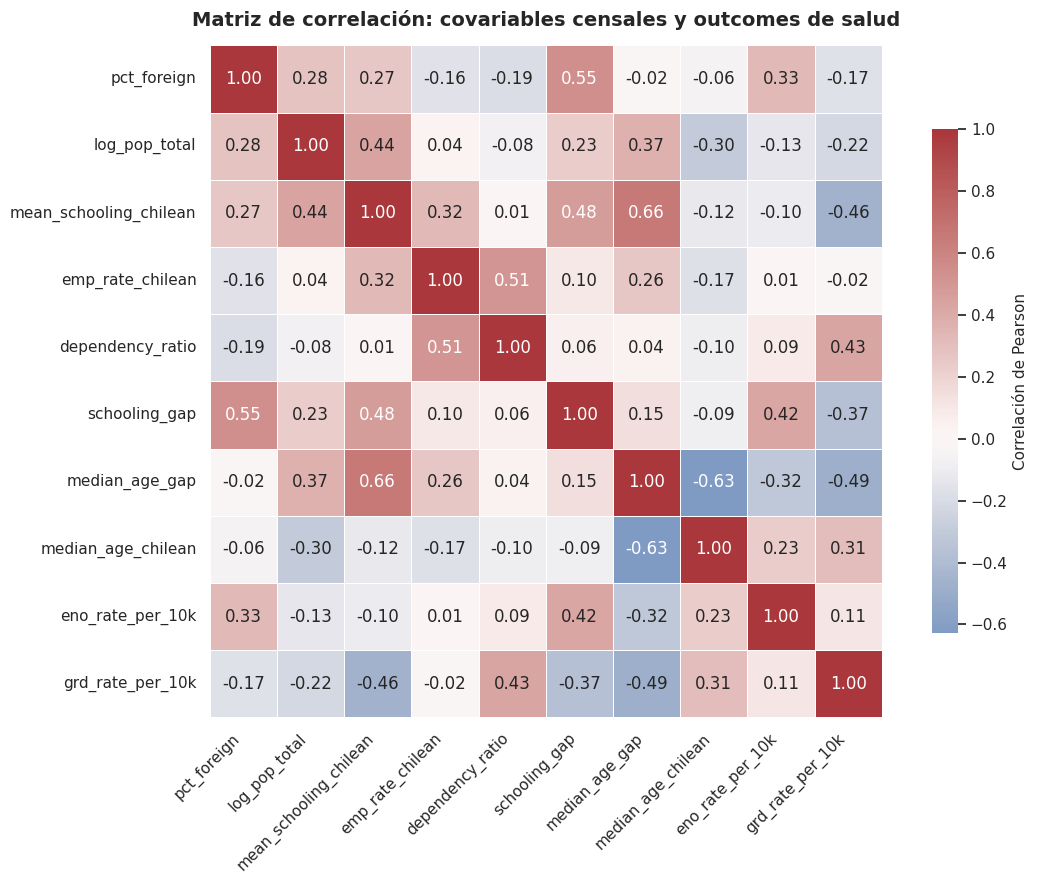

### Tres correlaciones más fuertes

,variable_1,variable_2,correlacion,abs_correlacion
20,mean_schooling_chilean,median_age_gap,0.657328,0.657328
39,median_age_gap,median_age_chilean,-0.629273,0.629273
4,pct_foreign,schooling_gap,0.545410,0.545410


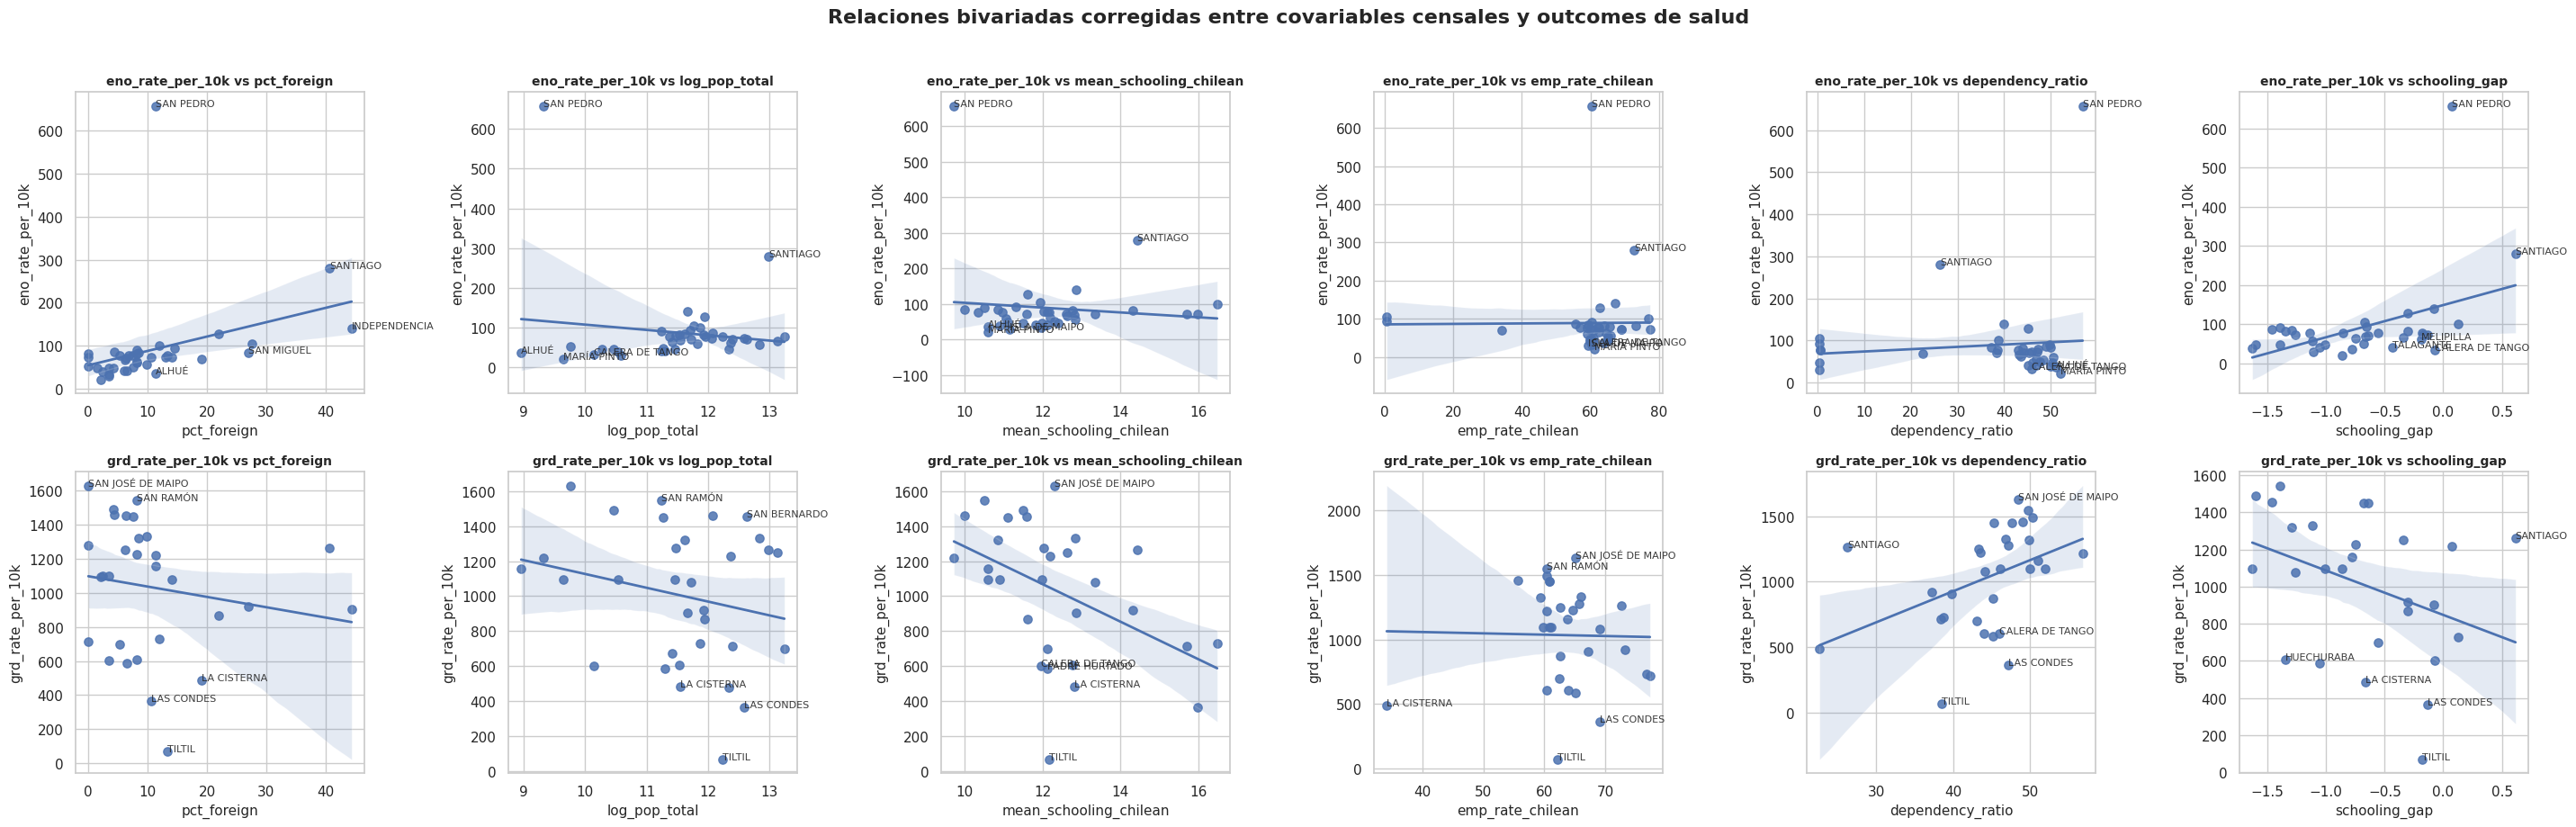

### Comunas con mayor comportamiento outlier visual

,codigo_comuna,nombre_comuna,apariciones_extremas,residual_promedio_abs,mayor_residual_abs
0,13101,SANTIAGO,8,274.837047,662.357665
5,13125,TILTIL,6,902.949190,981.130905
14,13505,SAN PEDRO,6,548.299493,568.804931
10,13403,CALERA DE TANGO,6,205.798184,468.630987
4,13114,LAS CONDES,5,628.303968,733.122710
3,13109,LA CISTERNA,5,522.518375,578.149148
8,13203,SAN JOSÉ DE MAIPO,4,557.025985,599.284442
13,13504,MARÍA PINTO,4,78.856926,91.890131
12,13502,ALHUÉ,4,66.461931,85.784420
7,13131,SAN RAMÓN,3,507.198657,515.922783



**SANTIAGO (13101).**
Esta comuna aparece repetidamente como observación extrema en las relaciones bivariadas. Una explicación plausible es que su carga sanitaria agregada no dependa solamente de su composición residencial, sino también de oferta de servicios, presencia de establecimientos de salud, derivaciones desde otras comunas, composición etaria o diferencias de registro. Por lo tanto, se interpreta como una señal territorial que requiere análisis adicional, no como evidencia causal individual.


**TILTIL (13125).**
Esta comuna aparece repetidamente como observación extrema en las relaciones bivariadas. Una explicación plausible es que su carga sanitaria agregada no dependa solamente de su composición residencial, sino también de oferta de servicios, presencia de establecimientos de salud, derivaciones desde otras comunas, composición etaria o diferencias de registro. Por lo tanto, se interpreta como una señal territorial que requiere análisis adicional, no como evidencia causal individual.



**Comentario Parte 2.**
El análisis exploratorio se rehizo usando población corregida y restringiendo el análisis principal a comunas de la Región Metropolitana. Esto evita correlaciones artificiales provocadas por población faltante, población mal consolidada después del merge o comunas fuera de la RM. Las relaciones siguen siendo ecológicas y descriptivas.


In [10]:
# ============================================================
# PARTE 2: ANÁLISIS EXPLORATORIO CROSS-DATASET
# ============================================================

mostrar_titulo_fern("## Parte 2 — Análisis exploratorio cross-dataset")

# ------------------------------------------------------------
# 2.1 Corrección de población total, tasas y base RM
# ------------------------------------------------------------

def coalescer_columnas_fern(df_fern, columnas_fern):
    """
    Toma varias columnas candidatas y devuelve la primera observación válida fila a fila.
    Esto corrige problemas del merge cuando aparecen pop_total_x, pop_total_y o pop_total vacío.
    """
    columnas_existentes_fern = [c for c in columnas_fern if c in df_fern.columns]

    if len(columnas_existentes_fern) == 0:
        return pd.Series(np.nan, index=df_fern.index)

    salida_fern = pd.Series(np.nan, index=df_fern.index)

    for col_fern in columnas_existentes_fern:
        serie_fern = pd.to_numeric(df_fern[col_fern], errors="coerce")
        salida_fern = salida_fern.combine_first(serie_fern)

    return salida_fern


def elegir_columna_menos_missing_fern(df_fern, candidatos_fern):
    """
    Selecciona, entre varias columnas candidatas, la que tenga más datos válidos y más de un valor único.
    """
    candidatos_fern = [c for c in candidatos_fern if c in df_fern.columns]

    if len(candidatos_fern) == 0:
        return None

    resumen_fern = []

    for col_fern in candidatos_fern:
        serie_fern = pd.to_numeric(df_fern[col_fern], errors="coerce")
        resumen_fern.append({
            "columna": col_fern,
            "n_validos": serie_fern.notna().sum(),
            "n_unicos": serie_fern.nunique(dropna=True)
        })

    resumen_fern = pd.DataFrame(resumen_fern)
    resumen_fern = resumen_fern[resumen_fern["n_unicos"] > 1]

    if len(resumen_fern) == 0:
        return None

    return resumen_fern.sort_values(["n_validos", "n_unicos"], ascending=False).iloc[0]["columna"]


df_analitica_fern = df_analitica_fern.copy()

df_analitica_fern["codigo_comuna"] = pd.to_numeric(df_analitica_fern["codigo_comuna"], errors="coerce")
df_analitica_fern = df_analitica_fern.dropna(subset=["codigo_comuna"]).copy()
df_analitica_fern["codigo_comuna"] = df_analitica_fern["codigo_comuna"].astype(int)

if "nombre_comuna" in df_analitica_fern.columns:
    df_analitica_fern["nombre_comuna"] = (
        df_analitica_fern["nombre_comuna"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({"NAN": np.nan})
    )

# ------------------------------------------------------------
# 2.2 Reconstrucción robusta de pop_total
# ------------------------------------------------------------

for col_fern in ["pop_total", "pop_total_x", "pop_total_y", "pop_chilean", "pop_foreign"]:
    if col_fern in df_analitica_fern.columns:
        df_analitica_fern[col_fern] = pd.to_numeric(df_analitica_fern[col_fern], errors="coerce")

pop_total_previa_fern = coalescer_columnas_fern(
    df_analitica_fern,
    [
        "pop_total",
        "pop_total_x",
        "pop_total_y",
        "population_total",
        "total_population",
        "census_pop_total"
    ]
)

if {"pop_chilean", "pop_foreign"}.issubset(df_analitica_fern.columns):
    pop_total_suma_fern = df_analitica_fern["pop_chilean"] + df_analitica_fern["pop_foreign"]
else:
    pop_total_suma_fern = pd.Series(np.nan, index=df_analitica_fern.index)

diferencia_relativa_fern = (
    (pop_total_previa_fern - pop_total_suma_fern).abs()
    / pop_total_suma_fern.replace(0, np.nan)
)

usar_suma_fern = (
    pop_total_suma_fern.notna()
    & (pop_total_suma_fern > 0)
    & (
        pop_total_previa_fern.isna()
        | (pop_total_previa_fern <= 0)
        | (diferencia_relativa_fern > 0.05)
    )
)

df_analitica_fern["pop_total_original_fern"] = pop_total_previa_fern
df_analitica_fern["pop_total"] = pop_total_previa_fern
df_analitica_fern.loc[usar_suma_fern, "pop_total"] = pop_total_suma_fern.loc[usar_suma_fern]

df_analitica_fern["log_pop_total"] = np.where(
    df_analitica_fern["pop_total"] > 0,
    np.log(df_analitica_fern["pop_total"]),
    np.nan
)

# ------------------------------------------------------------
# 2.3 Reconstrucción de variables derivadas
# ------------------------------------------------------------

if "pop_foreign" in df_analitica_fern.columns:
    df_analitica_fern["pct_foreign"] = np.where(
        df_analitica_fern["pop_total"] > 0,
        100 * df_analitica_fern["pop_foreign"] / df_analitica_fern["pop_total"],
        np.nan
    )

for col_fern in ["emp_rate_chilean", "emp_rate_foreign", "emp_rate_combined"]:
    if col_fern in df_analitica_fern.columns:
        df_analitica_fern[col_fern] = pd.to_numeric(df_analitica_fern[col_fern], errors="coerce")

if {"emp_rate_chilean", "emp_rate_foreign", "pop_chilean", "pop_foreign"}.issubset(df_analitica_fern.columns):
    emp_ch_fern = df_analitica_fern["emp_rate_chilean"].copy()
    emp_for_fern = df_analitica_fern["emp_rate_foreign"].copy()

    if np.nanmedian(emp_ch_fern) <= 1.5:
        emp_ch_fern = emp_ch_fern * 100

    if np.nanmedian(emp_for_fern) <= 1.5:
        emp_for_fern = emp_for_fern * 100

    numerador_emp_fern = (
        emp_ch_fern * df_analitica_fern["pop_chilean"]
        + emp_for_fern * df_analitica_fern["pop_foreign"]
    )

    denominador_emp_fern = df_analitica_fern["pop_chilean"] + df_analitica_fern["pop_foreign"]

    df_analitica_fern["emp_rate_combined"] = numerador_emp_fern / denominador_emp_fern

elif "emp_rate_combined" in df_analitica_fern.columns:
    if np.nanmedian(df_analitica_fern["emp_rate_combined"]) <= 1.5:
        df_analitica_fern["emp_rate_combined"] = df_analitica_fern["emp_rate_combined"] * 100

df_analitica_fern["pct_unemployed"] = np.where(
    df_analitica_fern["emp_rate_combined"].notna(),
    100 - df_analitica_fern["emp_rate_combined"],
    np.nan
)

for col_fern in [
    "mean_schooling_chilean",
    "mean_schooling_foreign",
    "median_age_chilean",
    "median_age_foreign",
    "dependency_ratio"
]:
    if col_fern in df_analitica_fern.columns:
        df_analitica_fern[col_fern] = pd.to_numeric(df_analitica_fern[col_fern], errors="coerce")

if {"mean_schooling_chilean", "mean_schooling_foreign"}.issubset(df_analitica_fern.columns):
    df_analitica_fern["schooling_gap"] = (
        df_analitica_fern["mean_schooling_chilean"]
        - df_analitica_fern["mean_schooling_foreign"]
    )

if {"mean_schooling_chilean", "mean_schooling_foreign", "pop_chilean", "pop_foreign"}.issubset(df_analitica_fern.columns):
    numerador_edu_fern = (
        df_analitica_fern["mean_schooling_chilean"] * df_analitica_fern["pop_chilean"]
        + df_analitica_fern["mean_schooling_foreign"] * df_analitica_fern["pop_foreign"]
    )

    denominador_edu_fern = df_analitica_fern["pop_chilean"] + df_analitica_fern["pop_foreign"]

    df_analitica_fern["mean_schooling_total"] = numerador_edu_fern / denominador_edu_fern

if {"median_age_foreign", "median_age_chilean"}.issubset(df_analitica_fern.columns):
    df_analitica_fern["median_age_gap"] = (
        df_analitica_fern["median_age_foreign"]
        - df_analitica_fern["median_age_chilean"]
    )

# ------------------------------------------------------------
# 2.4 Resolver outcomes y recalcular tasas sanitarias
# ------------------------------------------------------------

def resolver_columna_fern(df_fern, candidatos_fern, patrones_fern=None):
    for col_fern in candidatos_fern:
        if col_fern in df_fern.columns:
            return col_fern

    if patrones_fern is not None:
        for patron_fern in patrones_fern:
            for col_fern in df_fern.columns:
                if re.search(patron_fern, col_fern, flags=re.IGNORECASE):
                    return col_fern

    return None


OUTCOME_ENO_FERN = resolver_columna_fern(
    df_analitica_fern,
    candidatos_fern=["eno_total", "total_eno", "n_eno", "eno_count", "eno_notifications"],
    patrones_fern=[r"^eno.*total$", r"^total.*eno$", r"eno.*count", r"eno.*notif"]
)

OUTCOME_GRD_FERN = resolver_columna_fern(
    df_analitica_fern,
    candidatos_fern=["grd_total", "total_grd", "n_grd", "grd_count", "grd_cases"],
    patrones_fern=[r"^grd.*total$", r"^total.*grd$", r"grd.*count", r"grd.*case"]
)

if OUTCOME_ENO_FERN is None:
    raise ValueError("No se encontró columna válida de conteo ENO.")

if OUTCOME_GRD_FERN is None:
    raise ValueError("No se encontró columna válida de conteo GRD.")

df_analitica_fern[OUTCOME_ENO_FERN] = pd.to_numeric(df_analitica_fern[OUTCOME_ENO_FERN], errors="coerce")
df_analitica_fern[OUTCOME_GRD_FERN] = pd.to_numeric(df_analitica_fern[OUTCOME_GRD_FERN], errors="coerce")

df_analitica_fern["eno_rate_per_10k"] = np.where(
    df_analitica_fern["pop_total"] > 0,
    10000 * df_analitica_fern[OUTCOME_ENO_FERN] / df_analitica_fern["pop_total"],
    np.nan
)

df_analitica_fern["grd_rate_per_10k"] = np.where(
    df_analitica_fern["pop_total"] > 0,
    10000 * df_analitica_fern[OUTCOME_GRD_FERN] / df_analitica_fern["pop_total"],
    np.nan
)

df_analitica_fern = df_analitica_fern.replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# 2.5 Base RM corregida
# ------------------------------------------------------------

df_analitica_rm_fern = df_analitica_fern[
    (df_analitica_fern["codigo_comuna"] >= 13000)
    & (df_analitica_fern["codigo_comuna"] < 14000)
].copy()

df_analitica_rm_fern.to_csv(RUTA_ANALYTICAL_FERN, index=False)

mostrar_titulo_fern("### Diagnóstico posterior a corrección")

display(pd.DataFrame([{
    "n_total_tabla": len(df_analitica_fern),
    "n_rm": len(df_analitica_rm_fern),
    "pop_total_missing_rm": df_analitica_rm_fern["pop_total"].isna().sum(),
    "log_pop_total_missing_rm": df_analitica_rm_fern["log_pop_total"].isna().sum(),
    "pct_foreign_missing_rm": df_analitica_rm_fern["pct_foreign"].isna().sum(),
    "eno_rate_missing_rm": df_analitica_rm_fern["eno_rate_per_10k"].isna().sum(),
    "grd_rate_missing_rm": df_analitica_rm_fern["grd_rate_per_10k"].isna().sum(),
    "filas_con_pop_corregida_por_suma": int(usar_suma_fern.sum())
}]))

mostrar_titulo_fern("### Revisión de población y tasas corregidas")

columnas_revision_fern = [
    "codigo_comuna",
    "nombre_comuna",
    "pop_total_original_fern",
    "pop_chilean",
    "pop_foreign",
    "pop_total",
    "pct_foreign",
    "log_pop_total",
    OUTCOME_ENO_FERN,
    "eno_rate_per_10k",
    OUTCOME_GRD_FERN,
    "grd_rate_per_10k"
]

columnas_revision_fern = [c for c in columnas_revision_fern if c in df_analitica_rm_fern.columns]

display(
    df_analitica_rm_fern[columnas_revision_fern]
    .sort_values("codigo_comuna")
    .head(20)
)

# ------------------------------------------------------------
# 2.6 Selección de covariables para EDA
# ------------------------------------------------------------

df_eda_fern = df_analitica_rm_fern.copy()

col_educacion_fern = elegir_columna_menos_missing_fern(
    df_eda_fern,
    [
        "mean_schooling_total",
        "mean_schooling_chilean",
        "mean_schooling_foreign",
        "schooling_gap"
    ]
)

col_empleo_fern = elegir_columna_menos_missing_fern(
    df_eda_fern,
    [
        "pct_unemployed",
        "emp_rate_combined",
        "emp_rate_chilean",
        "emp_rate_foreign"
    ]
)

col_servicio_fern = elegir_columna_menos_missing_fern(
    df_eda_fern,
    [
        "dependency_ratio",
        "median_age_gap",
        "median_age_chilean",
        "median_age_foreign"
    ]
)

covariables_eda_fern = [
    "pct_foreign",
    "log_pop_total",
    col_educacion_fern,
    col_empleo_fern,
    col_servicio_fern,
    "schooling_gap",
    "median_age_gap",
    "median_age_chilean"
]

covariables_eda_fern = [
    c for c in covariables_eda_fern
    if c is not None and c in df_eda_fern.columns
]

covariables_eda_fern = list(dict.fromkeys(covariables_eda_fern))

for col_fern in covariables_eda_fern + ["eno_rate_per_10k", "grd_rate_per_10k"]:
    if col_fern in df_eda_fern.columns:
        df_eda_fern[col_fern] = pd.to_numeric(df_eda_fern[col_fern], errors="coerce")

mostrar_titulo_fern("### Covariables disponibles para EDA")

display(pd.DataFrame({"covariable": covariables_eda_fern}))

# ------------------------------------------------------------
# 2.7 Matriz de correlación
# ------------------------------------------------------------

variables_corr_fern = covariables_eda_fern[:8] + ["eno_rate_per_10k", "grd_rate_per_10k"]
variables_corr_fern = [v for v in variables_corr_fern if v in df_eda_fern.columns]
variables_corr_fern = list(dict.fromkeys(variables_corr_fern))

matriz_corr_fern = df_eda_fern[variables_corr_fern].corr(method="pearson", min_periods=5)

plt.figure(figsize=(12, 9))

sns.heatmap(
    matriz_corr_fern,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.6,
    cbar_kws={"shrink": 0.75, "label": "Correlación de Pearson"}
)

plt.title("Matriz de correlación: covariables censales y outcomes de salud", weight="bold", pad=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

RUTA_FIG_CORR_FERN = RUTA_OUTPUT_FERN / "fig_1_1_correlation_heatmap.png"
plt.savefig(RUTA_FIG_CORR_FERN, dpi=300, bbox_inches="tight")
plt.show()

pares_corr_fern = (
    matriz_corr_fern
    .where(np.triu(np.ones(matriz_corr_fern.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

pares_corr_fern.columns = ["variable_1", "variable_2", "correlacion"]
pares_corr_fern["abs_correlacion"] = pares_corr_fern["correlacion"].abs()
pares_corr_fern = pares_corr_fern.sort_values("abs_correlacion", ascending=False)

mostrar_titulo_fern("### Tres correlaciones más fuertes")

display(pares_corr_fern.head(3))

# ------------------------------------------------------------
# 2.8 Scatter small-multiple
# ------------------------------------------------------------

def obtener_indices_residuales_extremos_fern(df_fern, x_fern, y_fern, n_fern=5):
    datos_fern = df_fern[["codigo_comuna", "nombre_comuna", x_fern, y_fern]].dropna().copy()

    if len(datos_fern) < 5 or datos_fern[x_fern].nunique() < 2:
        return []

    coef_fern = np.polyfit(datos_fern[x_fern], datos_fern[y_fern], deg=1)
    datos_fern["pred"] = coef_fern[0] * datos_fern[x_fern] + coef_fern[1]
    datos_fern["abs_resid"] = (datos_fern[y_fern] - datos_fern["pred"]).abs()

    return datos_fern.sort_values("abs_resid", ascending=False).head(n_fern).index.tolist()


covariables_scatter_fern = [
    "pct_foreign",
    "log_pop_total",
    col_educacion_fern,
    col_empleo_fern,
    col_servicio_fern,
    "schooling_gap"
]

covariables_scatter_fern = [
    c for c in covariables_scatter_fern
    if c is not None and c in df_eda_fern.columns
]

covariables_scatter_fern = list(dict.fromkeys(covariables_scatter_fern))[:6]

outcomes_salud_fern = [
    c for c in ["eno_rate_per_10k", "grd_rate_per_10k"]
    if c in df_eda_fern.columns
]

fig_fern, axes_fern = plt.subplots(
    nrows=len(outcomes_salud_fern),
    ncols=len(covariables_scatter_fern),
    figsize=(4.8 * len(covariables_scatter_fern), 4.5 * len(outcomes_salud_fern)),
    squeeze=False
)

for i_fern, y_fern in enumerate(outcomes_salud_fern):
    for j_fern, x_fern in enumerate(covariables_scatter_fern):
        ax_fern = axes_fern[i_fern, j_fern]

        datos_plot_fern = df_eda_fern[
            ["codigo_comuna", "nombre_comuna", x_fern, y_fern]
        ].dropna().copy()

        if len(datos_plot_fern) >= 5 and datos_plot_fern[x_fern].nunique() >= 2:
            sns.regplot(
                data=datos_plot_fern,
                x=x_fern,
                y=y_fern,
                ax=ax_fern,
                ci=95,
                scatter_kws={"s": 45, "alpha": 0.85},
                line_kws={"linewidth": 2}
            )

            idx_extremos_fern = obtener_indices_residuales_extremos_fern(
                datos_plot_fern,
                x_fern,
                y_fern,
                n_fern=5
            )

            for idx_fern in idx_extremos_fern:
                fila_fern = datos_plot_fern.loc[idx_fern]
                etiqueta_fern = str(fila_fern["nombre_comuna"])[:18]

                ax_fern.text(
                    fila_fern[x_fern],
                    fila_fern[y_fern],
                    etiqueta_fern,
                    fontsize=8,
                    alpha=0.90
                )

        ax_fern.set_title(f"{y_fern} vs {x_fern}", fontsize=10, weight="bold")
        ax_fern.set_xlabel(x_fern)
        ax_fern.set_ylabel(y_fern)

fig_fern.suptitle("Relaciones bivariadas corregidas entre covariables censales y outcomes de salud", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()

RUTA_FIG_SCATTER_FERN = RUTA_OUTPUT_FERN / "fig_1_2_scatter_small_multiple.png"
plt.savefig(RUTA_FIG_SCATTER_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 2.9 Outliers visuales
# ------------------------------------------------------------

def tabla_outliers_bivariados_fern(df_fern, covariables_fern, outcomes_fern, n_por_panel_fern=5):
    registros_fern = []

    for x_fern in covariables_fern:
        for y_fern in outcomes_fern:
            datos_fern = df_fern[["codigo_comuna", "nombre_comuna", x_fern, y_fern]].dropna().copy()

            if len(datos_fern) < 5 or datos_fern[x_fern].nunique() < 2:
                continue

            coef_fern = np.polyfit(datos_fern[x_fern], datos_fern[y_fern], deg=1)
            datos_fern["pred"] = coef_fern[0] * datos_fern[x_fern] + coef_fern[1]
            datos_fern["resid"] = datos_fern[y_fern] - datos_fern["pred"]
            datos_fern["abs_resid"] = datos_fern["resid"].abs()

            extremos_fern = datos_fern.sort_values("abs_resid", ascending=False).head(n_por_panel_fern)

            for _, fila_fern in extremos_fern.iterrows():
                registros_fern.append({
                    "codigo_comuna": fila_fern["codigo_comuna"],
                    "nombre_comuna": fila_fern["nombre_comuna"],
                    "covariable": x_fern,
                    "outcome": y_fern,
                    "residual": fila_fern["resid"],
                    "abs_residual": fila_fern["abs_resid"]
                })

    if len(registros_fern) == 0:
        return pd.DataFrame(), pd.DataFrame()

    detalle_fern = pd.DataFrame(registros_fern)

    resumen_fern = (
        detalle_fern
        .groupby(["codigo_comuna", "nombre_comuna"], as_index=False)
        .agg(
            apariciones_extremas=("codigo_comuna", "size"),
            residual_promedio_abs=("abs_residual", "mean"),
            mayor_residual_abs=("abs_residual", "max")
        )
        .sort_values(["apariciones_extremas", "mayor_residual_abs"], ascending=False)
    )

    return detalle_fern, resumen_fern


outliers_detalle_fern, outliers_resumen_fern = tabla_outliers_bivariados_fern(
    df_eda_fern,
    covariables_scatter_fern,
    outcomes_salud_fern,
    n_por_panel_fern=5
)

mostrar_titulo_fern("### Comunas con mayor comportamiento outlier visual")

display(outliers_resumen_fern.head(10))

parrafos_outliers_fern = []

for _, fila_fern in outliers_resumen_fern.head(2).iterrows():
    parrafos_outliers_fern.append(
        f"""
**{fila_fern["nombre_comuna"]} ({int(fila_fern["codigo_comuna"])}).**
Esta comuna aparece repetidamente como observación extrema en las relaciones bivariadas. Una explicación plausible es que su carga sanitaria agregada no dependa solamente de su composición residencial, sino también de oferta de servicios, presencia de establecimientos de salud, derivaciones desde otras comunas, composición etaria o diferencias de registro. Por lo tanto, se interpreta como una señal territorial que requiere análisis adicional, no como evidencia causal individual.
"""
    )

display(Markdown("\n".join(parrafos_outliers_fern)))

texto_parte2_fern = """
**Comentario Parte 2.**
El análisis exploratorio se rehizo usando población corregida y restringiendo el análisis principal a comunas de la Región Metropolitana. Esto evita correlaciones artificiales provocadas por población faltante, población mal consolidada después del merge o comunas fuera de la RM. Las relaciones siguen siendo ecológicas y descriptivas.
"""

display(Markdown(texto_parte2_fern))

**Resultados del análisis exploratorio**

La matriz de correlación muestra varias relaciones interesantes entre las variables. Las tres más fuertes son:

* `mean_schooling_chilean` con `median_age_gap` (r = 0.657): En comunas con mayor escolaridad promedio, la brecha de edad entre extranjeros y chilenos tiende a ser mayor.
* `median_age_gap` con `median_age_chilean` (r = -0.629): A mayor edad mediana de la población chilena, menor es la diferencia de edad con los extranjeros.
* `pct_foreign` con `schooling_gap` (r = 0.545). Comunas con mayor proporción de extranjeros tienden a tener una mayor brecha de escolaridad.

En los outcomes de salud, `pct_foreign` se relaciona positivamente con `eno_rate_per_10k` (r = 0.33) y negativamente con `grd_rate_per_10k` (r = -0.17). Esto sugiere que las comunas con más extranjeros reportan más enfermedades, pero menos egresos hospitalarios por habitante. Puede estar asociado a diferencias de acceso o al perfil etario de la población migrante, que en general es más joven.

Las comunas más atípicas en las relaciones bivariadas fueron **Santiago** y **Tiltil**, ambas con residuos promedio altos y apareciendo varias veces como extremos. Santiago es esperable porque concentra servicios de salud que atienden a toda la región, lo que eleva sus tasas. Tiltil, en cambio, es una comuna pequeña y rural, donde cambios pequeños en valores absolutos generan variaciones grandes en las tasas.


---
## Parte 3 — Modelos de conteo: Poisson y Negative Binomial

Los outcomes ENO y GRD son conteos de eventos que son un número de notificaciones o egresos por comuna, por lo que los modelos estadísticos apropiados son modelos de conteo y no regresión lineal. En esta parte ajustamos dos tipos:

**Modelo Poisson:** es el modelo de conteo más simple. Asume que la varianza del outcome es igual a la media. Usamos `log_pop_total` como *offset* para modelar tasas por habitante en lugar de conteos absolutos, lo que permite comparar comunas de distinto tamaño.

**Modelo Negative Binomial:** cuando los datos tienen más variabilidad que la que Poisson puede capturar el fenómeno llamado sobredispersión, el Negative Binomial es más apropiado. Se elige automáticamente cuando el estadístico de dispersión del Poisson supera 1.5.

Los coeficientes se presentan en dos formas:
- **Coeficientes en escala log:** los que entrega el modelo directamente
- **IRR (Incidence Rate Ratios):** exponencial de los coeficientes, que se interpretan como el cambio multiplicativo esperado en la tasa por cada aumento de una desviación estándar en la covariable, todo esto ya que estandarizamos las variables antes de modelar

Las covariables se seleccionan automáticamente priorizando: porcentaje de extranjeros, escolaridad, empleo y dependencia demográfica. También se calcula el VIF (Variance Inflation Factor) para detectar colinealidad.

In [11]:
# ============================================================
# PARTE 3: MODELOS DE CONTEO — POISSON Y NEGATIVE BINOMIAL
# ============================================================

mostrar_titulo_fern("## Parte 3 — Modelos de conteo")

# ------------------------------------------------------------
# 3.1 Base de modelamiento
# ------------------------------------------------------------

df_modelos_fern = df_analitica_rm_fern.copy()

# Asegurar variables numéricas centrales.
columnas_numericas_base_fern = [
    OUTCOME_ENO_FERN,
    OUTCOME_GRD_FERN,
    "pop_total",
    "log_pop_total",
    "pct_foreign",
    "pct_unemployed",
    "emp_rate_combined",
    "emp_rate_chilean",
    "emp_rate_foreign",
    "mean_schooling_total",
    "mean_schooling_chilean",
    "mean_schooling_foreign",
    "schooling_gap",
    "dependency_ratio",
    "median_age_gap",
    "median_age_chilean",
    "median_age_foreign"
]

for col_fern in columnas_numericas_base_fern:
    if col_fern in df_modelos_fern.columns:
        df_modelos_fern[col_fern] = pd.to_numeric(df_modelos_fern[col_fern], errors="coerce")

# ------------------------------------------------------------
# 3.2 Selección ordenada de covariables
# ------------------------------------------------------------

def seleccionar_primera_valida_fern(df_fern, candidatos_fern, n_min_fern=20):
    """
    Selecciona la primera columna candidata con suficiente información válida.
    """
    for col_fern in candidatos_fern:
        if col_fern in df_fern.columns:
            serie_fern = pd.to_numeric(df_fern[col_fern], errors="coerce")

            if serie_fern.notna().sum() >= n_min_fern and serie_fern.nunique(dropna=True) > 1:
                return col_fern

    return None


col_migracion_modelo_fern = seleccionar_primera_valida_fern(
    df_modelos_fern,
    ["pct_foreign"],
    n_min_fern=20
)

col_educacion_modelo_fern = seleccionar_primera_valida_fern(
    df_modelos_fern,
    [
        "mean_schooling_total",
        "mean_schooling_chilean",
        "mean_schooling_foreign",
        "schooling_gap"
    ],
    n_min_fern=20
)

col_empleo_modelo_fern = seleccionar_primera_valida_fern(
    df_modelos_fern,
    [
        "pct_unemployed",
        "emp_rate_combined",
        "emp_rate_chilean",
        "emp_rate_foreign"
    ],
    n_min_fern=20
)

col_servicio_modelo_fern = seleccionar_primera_valida_fern(
    df_modelos_fern,
    [
        "dependency_ratio",
        "median_age_chilean",
        "median_age_gap",
        "median_age_foreign"
    ],
    n_min_fern=20
)

covariables_modelo_fern = [
    col_migracion_modelo_fern,
    col_educacion_modelo_fern,
    col_empleo_modelo_fern,
    col_servicio_modelo_fern
]

covariables_modelo_fern = [
    c for c in covariables_modelo_fern
    if c is not None and c in df_modelos_fern.columns
]

covariables_modelo_fern = list(dict.fromkeys(covariables_modelo_fern))

mostrar_titulo_fern("### Covariables seleccionadas para modelos de conteo")

display(pd.DataFrame({
    "rol": ["migracion", "educacion", "empleo", "servicio_o_proxy"],
    "variable": [
        col_migracion_modelo_fern,
        col_educacion_modelo_fern,
        col_empleo_modelo_fern,
        col_servicio_modelo_fern
    ]
}))

# ------------------------------------------------------------
# 3.3 Funciones de modelamiento
# ------------------------------------------------------------

def estandarizar_covariables_modelo_fern(df_fern, variables_fern):
    """
    Estandariza covariables para mejorar estabilidad numérica.
    Los IRR se interpretan por aumento de una desviación estándar.
    """
    df_fern = df_fern.copy()
    medias_fern = {}
    desvios_fern = {}

    for col_fern in variables_fern:
        media_fern = df_fern[col_fern].mean()
        sd_fern = df_fern[col_fern].std(ddof=0)

        medias_fern[col_fern] = media_fern
        desvios_fern[col_fern] = sd_fern

        if pd.notna(sd_fern) and sd_fern > 0:
            df_fern[col_fern] = (df_fern[col_fern] - media_fern) / sd_fern

    return df_fern, medias_fern, desvios_fern


def preparar_base_conteo_fern(df_fern, outcome_fern, covariables_fern):
    """
    Prepara base completa para modelo de conteo con offset poblacional.
    """
    columnas_fern = [
        "codigo_comuna",
        "nombre_comuna",
        outcome_fern,
        "pop_total",
        "log_pop_total"
    ] + covariables_fern

    columnas_fern = [c for c in columnas_fern if c in df_fern.columns]

    datos_fern = df_fern[columnas_fern].copy()

    for col_fern in [outcome_fern, "pop_total", "log_pop_total"] + covariables_fern:
        if col_fern in datos_fern.columns:
            datos_fern[col_fern] = pd.to_numeric(datos_fern[col_fern], errors="coerce")

    datos_fern = datos_fern.replace([np.inf, -np.inf], np.nan)
    datos_fern = datos_fern.dropna(subset=[outcome_fern, "pop_total", "log_pop_total"] + covariables_fern)
    datos_fern = datos_fern[(datos_fern[outcome_fern] >= 0) & (datos_fern["pop_total"] > 0)].copy()

    return datos_fern


def calcular_vif_fern(df_fern, variables_fern):
    """
    Calcula VIF para diagnosticar colinealidad.
    """
    if len(variables_fern) < 2:
        return pd.DataFrame({
            "variable": variables_fern,
            "VIF": np.nan,
            "nota": "Menos de dos covariables."
        })

    datos_vif_fern = df_fern[variables_fern].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

    if datos_vif_fern.shape[0] <= len(variables_fern) + 1:
        return pd.DataFrame({
            "variable": variables_fern,
            "VIF": np.nan,
            "nota": "N insuficiente para calcular VIF estable."
        })

    X_vif_fern = sm.add_constant(datos_vif_fern, has_constant="add")

    salida_fern = []

    for i_fern, col_fern in enumerate(X_vif_fern.columns):
        if col_fern == "const":
            continue

        try:
            vif_fern = variance_inflation_factor(X_vif_fern.values, i_fern)
        except Exception:
            vif_fern = np.nan

        salida_fern.append({
            "variable": col_fern,
            "VIF": vif_fern,
            "nota": "OK"
        })

    return pd.DataFrame(salida_fern).sort_values("VIF", ascending=False)


def ajustar_poisson_fern(df_fern, outcome_fern, covariables_fern):
    """
    Ajusta GLM Poisson con offset log_pop_total.
    """
    datos_original_fern = preparar_base_conteo_fern(df_fern, outcome_fern, covariables_fern)

    if len(datos_original_fern) <= len(covariables_fern) + 2:
        raise ValueError(
            f"N insuficiente para ajustar Poisson de {outcome_fern}. "
            f"N={len(datos_original_fern)}, k={len(covariables_fern)}."
        )

    datos_modelo_fern, medias_fern, desvios_fern = estandarizar_covariables_modelo_fern(
        datos_original_fern,
        covariables_fern
    )

    y_fern = datos_modelo_fern[outcome_fern].astype(float)
    X_fern = sm.add_constant(datos_modelo_fern[covariables_fern].astype(float), has_constant="add")

    modelo_fern = sm.GLM(
        y_fern,
        X_fern,
        family=sm.families.Poisson(),
        offset=datos_modelo_fern["log_pop_total"].astype(float)
    )

    resultado_fern = modelo_fern.fit()

    return resultado_fern, datos_original_fern, datos_modelo_fern, medias_fern, desvios_fern


def ajustar_negative_binomial_fern(df_fern, outcome_fern, covariables_fern):
    """
    Ajusta Negative Binomial con offset log_pop_total.
    """
    datos_original_fern = preparar_base_conteo_fern(df_fern, outcome_fern, covariables_fern)

    if len(datos_original_fern) <= len(covariables_fern) + 2:
        raise ValueError(
            f"N insuficiente para ajustar Negative Binomial de {outcome_fern}. "
            f"N={len(datos_original_fern)}, k={len(covariables_fern)}."
        )

    datos_modelo_fern, medias_fern, desvios_fern = estandarizar_covariables_modelo_fern(
        datos_original_fern,
        covariables_fern
    )

    y_fern = datos_modelo_fern[outcome_fern].astype(float)
    X_fern = sm.add_constant(datos_modelo_fern[covariables_fern].astype(float), has_constant="add")

    try:
        modelo_fern = sm.NegativeBinomial(
            y_fern,
            X_fern,
            offset=datos_modelo_fern["log_pop_total"].astype(float)
        )

        resultado_fern = modelo_fern.fit(disp=False, maxiter=1000)
        tipo_fern = "NegativeBinomial discreto"

    except Exception:
        modelo_fern = sm.GLM(
            y_fern,
            X_fern,
            family=sm.families.NegativeBinomial(alpha=1.0),
            offset=datos_modelo_fern["log_pop_total"].astype(float)
        )

        resultado_fern = modelo_fern.fit()
        tipo_fern = "GLM NegativeBinomial alpha=1"

    return resultado_fern, datos_original_fern, datos_modelo_fern, medias_fern, desvios_fern, tipo_fern


def tabla_coeficientes_fern(resultado_fern):
    """
    Tabla de coeficientes estándar.
    """
    params_fern = resultado_fern.params.copy()
    bse_fern = resultado_fern.bse.copy()
    pvalues_fern = resultado_fern.pvalues.copy()
    conf_fern = resultado_fern.conf_int()

    if isinstance(conf_fern, np.ndarray):
        conf_fern = pd.DataFrame(conf_fern, index=params_fern.index, columns=["ci_low", "ci_high"])
    else:
        conf_fern.columns = ["ci_low", "ci_high"]

    tabla_fern = pd.DataFrame({
        "coef": params_fern,
        "std_error": bse_fern,
        "z_or_t": params_fern / bse_fern,
        "p_value": pvalues_fern,
        "ci_low": conf_fern["ci_low"],
        "ci_high": conf_fern["ci_high"]
    })

    tabla_fern = tabla_fern.drop(index="alpha", errors="ignore")

    return tabla_fern


def tabla_irr_fern(resultado_fern):
    """
    Convierte coeficientes log-lineales en IRR.
    """
    tabla_fern = tabla_coeficientes_fern(resultado_fern)

    tabla_fern["IRR"] = np.exp(tabla_fern["coef"])
    tabla_fern["IRR_ci_low"] = np.exp(tabla_fern["ci_low"])
    tabla_fern["IRR_ci_high"] = np.exp(tabla_fern["ci_high"])

    return tabla_fern[
        [
            "coef",
            "std_error",
            "z_or_t",
            "p_value",
            "IRR",
            "IRR_ci_low",
            "IRR_ci_high"
        ]
    ]


def metricas_ajuste_fern(resultado_fern):
    """
    Métricas de ajuste del modelo.
    """
    salida_fern = {
        "AIC": getattr(resultado_fern, "aic", np.nan),
        "deviance": getattr(resultado_fern, "deviance", np.nan),
        "pearson_chi2": getattr(resultado_fern, "pearson_chi2", np.nan),
        "df_resid": getattr(resultado_fern, "df_resid", np.nan)
    }

    if pd.notna(salida_fern["pearson_chi2"]) and pd.notna(salida_fern["df_resid"]) and salida_fern["df_resid"] > 0:
        salida_fern["dispersion"] = salida_fern["pearson_chi2"] / salida_fern["df_resid"]
    else:
        salida_fern["dispersion"] = np.nan

    return pd.DataFrame([salida_fern])


# ------------------------------------------------------------
# 3.4 Diagnóstico de disponibilidad y colinealidad
# ------------------------------------------------------------

datos_disponibles_eno_fern = preparar_base_conteo_fern(df_modelos_fern, OUTCOME_ENO_FERN, covariables_modelo_fern)
datos_disponibles_grd_fern = preparar_base_conteo_fern(df_modelos_fern, OUTCOME_GRD_FERN, covariables_modelo_fern)

mostrar_titulo_fern("### Disponibilidad para modelos")

display(pd.DataFrame([
    {
        "modelo": "ENO",
        "outcome": OUTCOME_ENO_FERN,
        "n_modelable": len(datos_disponibles_eno_fern),
        "covariables": covariables_modelo_fern
    },
    {
        "modelo": "GRD",
        "outcome": OUTCOME_GRD_FERN,
        "n_modelable": len(datos_disponibles_grd_fern),
        "covariables": covariables_modelo_fern
    }
]))

mostrar_titulo_fern("### Diagnóstico VIF")

display(calcular_vif_fern(datos_disponibles_eno_fern, covariables_modelo_fern))

# ------------------------------------------------------------
# 3.5 Poisson ENO
# ------------------------------------------------------------

resultado_poisson_eno_fern, datos_eno_original_fern, datos_eno_modelo_fern, medias_eno_fern, desvios_eno_fern = ajustar_poisson_fern(
    df_modelos_fern,
    OUTCOME_ENO_FERN,
    covariables_modelo_fern
)

tabla_poisson_eno_fern = tabla_coeficientes_fern(resultado_poisson_eno_fern)
irr_poisson_eno_fern = tabla_irr_fern(resultado_poisson_eno_fern)
fit_poisson_eno_fern = metricas_ajuste_fern(resultado_poisson_eno_fern)

mostrar_titulo_fern("### Poisson ENO — Coefficient table")

display(tabla_poisson_eno_fern)

mostrar_titulo_fern("### Poisson ENO — IRR table")

display(irr_poisson_eno_fern)

mostrar_titulo_fern("### Poisson ENO — Model fit")

display(fit_poisson_eno_fern)

# ------------------------------------------------------------
# 3.6 Sobredispersión y Negative Binomial ENO
# ------------------------------------------------------------

dispersion_eno_fern = fit_poisson_eno_fern.loc[0, "dispersion"]

mostrar_titulo_fern(f"### Dispersión Poisson ENO: {dispersion_eno_fern:.3f}")

resultado_nb_eno_fern, datos_nb_eno_original_fern, datos_nb_eno_modelo_fern, medias_nb_eno_fern, desvios_nb_eno_fern, tipo_nb_eno_fern = ajustar_negative_binomial_fern(
    df_modelos_fern,
    OUTCOME_ENO_FERN,
    covariables_modelo_fern
)

tabla_nb_eno_fern = tabla_coeficientes_fern(resultado_nb_eno_fern)
irr_nb_eno_fern = tabla_irr_fern(resultado_nb_eno_fern)

comparacion_eno_fern = (
    tabla_poisson_eno_fern[["coef", "std_error", "p_value"]]
    .rename(columns={
        "coef": "coef_poisson",
        "std_error": "se_poisson",
        "p_value": "p_poisson"
    })
    .join(
        tabla_nb_eno_fern[["coef", "std_error", "p_value"]]
        .rename(columns={
            "coef": "coef_nb",
            "std_error": "se_nb",
            "p_value": "p_nb"
        }),
        how="outer"
    )
)

comparacion_eno_fern["cambia_conclusion_5pct"] = (
    (comparacion_eno_fern["p_poisson"] < 0.05)
    !=
    (comparacion_eno_fern["p_nb"] < 0.05)
)

mostrar_titulo_fern(f"### Negative Binomial ENO — {tipo_nb_eno_fern}")

display(tabla_nb_eno_fern)

mostrar_titulo_fern("### Comparación Poisson vs Negative Binomial ENO")

display(comparacion_eno_fern)

if pd.notna(dispersion_eno_fern) and dispersion_eno_fern > 1.5:
    modelo_eno_principal_fern = resultado_nb_eno_fern
    datos_eno_principal_original_fern = datos_nb_eno_original_fern
    datos_eno_principal_modelo_fern = datos_nb_eno_modelo_fern
    irr_eno_principal_fern = irr_nb_eno_fern
    familia_eno_principal_fern = "Negative Binomial"
else:
    modelo_eno_principal_fern = resultado_poisson_eno_fern
    datos_eno_principal_original_fern = datos_eno_original_fern
    datos_eno_principal_modelo_fern = datos_eno_modelo_fern
    irr_eno_principal_fern = irr_poisson_eno_fern
    familia_eno_principal_fern = "Poisson"

cov_eno_principal_fern = covariables_modelo_fern

mostrar_titulo_fern(f"### Modelo ENO recomendado: {familia_eno_principal_fern}")

# ------------------------------------------------------------
# 3.7 Modelo de conteo GRD
# ------------------------------------------------------------

resultado_poisson_grd_fern, datos_grd_original_fern, datos_grd_modelo_fern, medias_grd_fern, desvios_grd_fern = ajustar_poisson_fern(
    df_modelos_fern,
    OUTCOME_GRD_FERN,
    covariables_modelo_fern
)

tabla_poisson_grd_fern = tabla_coeficientes_fern(resultado_poisson_grd_fern)
irr_poisson_grd_fern = tabla_irr_fern(resultado_poisson_grd_fern)
fit_poisson_grd_fern = metricas_ajuste_fern(resultado_poisson_grd_fern)

dispersion_grd_fern = fit_poisson_grd_fern.loc[0, "dispersion"]

if pd.notna(dispersion_grd_fern) and dispersion_grd_fern > 1.5:
    resultado_nb_grd_fern, datos_nb_grd_original_fern, datos_nb_grd_modelo_fern, medias_nb_grd_fern, desvios_nb_grd_fern, tipo_nb_grd_fern = ajustar_negative_binomial_fern(
        df_modelos_fern,
        OUTCOME_GRD_FERN,
        covariables_modelo_fern
    )

    resultado_grd_principal_fern = resultado_nb_grd_fern
    datos_grd_principal_original_fern = datos_nb_grd_original_fern
    datos_grd_principal_modelo_fern = datos_nb_grd_modelo_fern
    irr_grd_principal_fern = tabla_irr_fern(resultado_nb_grd_fern)
    familia_grd_principal_fern = "Negative Binomial"

else:
    resultado_grd_principal_fern = resultado_poisson_grd_fern
    datos_grd_principal_original_fern = datos_grd_original_fern
    datos_grd_principal_modelo_fern = datos_grd_modelo_fern
    irr_grd_principal_fern = irr_poisson_grd_fern
    familia_grd_principal_fern = "Poisson"

cov_grd_principal_fern = covariables_modelo_fern

mostrar_titulo_fern(f"### Dispersión Poisson GRD: {dispersion_grd_fern:.3f}")
mostrar_titulo_fern(f"### Modelo GRD recomendado: {familia_grd_principal_fern}")

mostrar_titulo_fern("### GRD — IRR table")

display(irr_grd_principal_fern)

efectos_grd_fern = irr_grd_principal_fern.drop(index="const", errors="ignore").copy()
efectos_grd_fern["distancia_a_1"] = (efectos_grd_fern["IRR"] - 1).abs()
efectos_grd_fern = efectos_grd_fern.sort_values("distancia_a_1", ascending=False)

mostrar_titulo_fern("### Efectos GRD más grandes")

display(efectos_grd_fern.head(3))

variable_grd_mayor_fern = efectos_grd_fern.index[0]
irr_grd_mayor_fern = efectos_grd_fern.iloc[0]["IRR"]

texto_parte3_fern = f"""
**Comentario Parte 3.**
El modelo ENO fue estimado con **{len(datos_eno_principal_original_fern)} comunas** y el modelo GRD con **{len(datos_grd_principal_original_fern)} comunas**.
Para ENO, la dispersión Poisson fue **{dispersion_eno_fern:.3f}**, por lo que el modelo recomendado fue **{familia_eno_principal_fern}**.
Para GRD, la dispersión Poisson fue **{dispersion_grd_fern:.3f}**, por lo que el modelo recomendado fue **{familia_grd_principal_fern}**.

En GRD, la covariable con mayor distancia respecto de IRR = 1 fue **{variable_grd_mayor_fern}**, con IRR aproximado de **{irr_grd_mayor_fern:.3f}**. Como las covariables fueron estandarizadas, este IRR se interpreta como el cambio multiplicativo esperado en el conteo por un aumento de una desviación estándar en la covariable, manteniendo constante el resto y usando población como offset.
"""

display(Markdown(texto_parte3_fern))

## Parte 3 — Modelos de conteo

### Covariables seleccionadas para modelos de conteo

,rol,variable
0,migracion,pct_foreign
1,educacion,mean_schooling_total
2,empleo,pct_unemployed
3,servicio_o_proxy,dependency_ratio


### Disponibilidad para modelos

,modelo,outcome,n_modelable,covariables
0,ENO,eno_total,36,"[pct_foreign, mean_schooling_total, pct_unempl..."
1,GRD,grd_total,27,"[pct_foreign, mean_schooling_total, pct_unempl..."


...

### GRD — IRR table

,coef,std_error,z_or_t,p_value,IRR,IRR_ci_low,IRR_ci_high
const,-2.315341,0.084884,-27.276607,8.037804e-164,0.098732,0.083600,0.116604
pct_foreign,-0.028391,0.156729,-0.181144,8.562546e-01,0.972009,0.714927,1.321534
mean_schooling_total,-0.311382,0.169023,-1.842246,6.543911e-02,0.732434,0.525891,1.020096
pct_unemployed,-0.195449,0.154762,-1.262902,2.066243e-01,0.822465,0.607273,1.113912
dependency_ratio,-0.040817,0.194626,-0.209723,8.338838e-01,0.960004,0.655553,1.405849


### Efectos GRD más grandes

,coef,std_error,z_or_t,p_value,IRR,IRR_ci_low,IRR_ci_high,distancia_a_1
mean_schooling_total,-0.311382,0.169023,-1.842246,0.065439,0.732434,0.525891,1.020096,0.267566
pct_unemployed,-0.195449,0.154762,-1.262902,0.206624,0.822465,0.607273,1.113912,0.177535
dependency_ratio,-0.040817,0.194626,-0.209723,0.833884,0.960004,0.655553,1.405849,0.039996



**Comentario Parte 3.**
El modelo ENO fue estimado con **36 comunas** y el modelo GRD con **27 comunas**.
Para ENO, la dispersión Poisson fue **237.142**, por lo que el modelo recomendado fue **Negative Binomial**.
Para GRD, la dispersión Poisson fue **2333.156**, por lo que el modelo recomendado fue **Negative Binomial**.

En GRD, la covariable con mayor distancia respecto de IRR = 1 fue **mean_schooling_total**, con IRR aproximado de **0.732**. Como las covariables fueron estandarizadas, este IRR se interpreta como el cambio multiplicativo esperado en el conteo por un aumento de una desviación estándar en la covariable, manteniendo constante el resto y usando población como offset.


**Resultados de los modelos de conteo**

Las covariables usadas en ambos modelos fueron `pct_foreign`, `mean_schooling_total`, `pct_unemployed` y `dependency_ratio`.
El diagnóstico VIF muestra que no hay problemas de colinealidad, todos los valores están bajo 1.53.

**Modelo ENO 36 comunas**
La dispersión en Poisson fue 237.14, muy por sobre 1.5, lo que confirma sobredispersión fuerte y justifica usar Negative Binomial:

* `pct_foreign` es la única variable significativa p < 0.001, con IRR = 1.581. Esto implica que un aumento de una desviación estándar en el porcentaje de extranjeros se asocia a una tasa ENO esperada 58% mayor, manteniendo el resto constante. Es la relación más clara del análisis.
* `mean_schooling_total` tiene IRR = 0.807 con p = 0.008, lo que sugiere que mayor escolaridad se asocia a menos notificaciones, aunque esto hay que mirarlo con cautela.
* `pct_unemployed` y `dependency_ratio` no son significativas al 5%.

**Modelo GRD 27 comunas**
La dispersión en Poisson fue 2333.16, nuevamente con sobredispersión fuerte, por lo que también se usa Negative Binomial.

En este caso, ninguna variable resulta significativa. Los IRR están muy cerca de 1, lo que indica que las variables censales no explican bien la variación en egresos hospitalarios. Tiene sentido, porque estos egresos dependen más de la oferta hospitalaria y la complejidad clínica que de la composición demográfica de la comuna.


---
## Parte 4 — Regresión OLS para outcome continuo GRD

Además de modelar los conteos de egresos, también podemos modelar outcomes continuos asociados al GRD, como la longitud de estadía promedio(`grd_mean_los`), la severidad promedio (`grd_mean_severity`) o la tasa de mortalidad intrahospitalaria. Estos outcomes no son conteos de eventos sino promedios comunales, por lo que se modelan con regresión lineal OLS en lugar de modelos de conteo.

El código selecciona automáticamente el mejor outcome continuo disponible. Si existen columnas como `grd_mean_los` o `grd_mean_severity`, las prioriza. Si no están disponibles, usa `grd_rate_per_10k` como variable de respaldo.

El modelo OLS se ajusta con las mismas covariables que los modelos de conteo, estandarizadas para facilitar la comparación de coeficientes. Adicionalmente se reportan errores robustos HC3, que son más apropiados cuando existe heterocedasticidad (varianza no constante de los residuos), algo bastante común en análisis ecológicos comunales.

Los diagnósticos incluyen:
- **Gráfico de residuos vs valores ajustados:** para detectar patrones sistemáticos
- **QQ plot:** para evaluar si los residuos tienen distribución aproximadamente normal
- **Test de Shapiro-Wilk:** normalidad de residuos
- **Test de Breusch-Pagan:** heterocedasticidad

## Parte 4 — Regresión de outcome continuo GRD

### Outcome continuo seleccionado

,outcome_continuo,tipo_outcome
0,grd_mean_los,outcome_continuo_grd_directo



**Selección del outcome.**
Se selecciona `grd_mean_los` porque representa una dimensión continua asociada a GRD a nivel comunal.
A diferencia de los conteos ENO y GRD, este outcome no se modela como frecuencia de eventos con offset, sino como variable continua mediante OLS.


### Disponibilidad para OLS

...

,coef,std_error,z_or_t,p_value,ci_low,ci_high
const,5.884822,0.119621,49.195458,5.353841e-24,5.636743,6.132902
pct_foreign,-0.035658,0.202807,-0.175823,8.620417e-01,-0.456254,0.384938
mean_schooling_total,0.016536,0.216957,0.076217,9.399355e-01,-0.433405,0.466476
pct_unemployed,-0.205103,0.210419,-0.974735,3.402883e-01,-0.641485,0.231280
dependency_ratio,-0.213055,0.250562,-0.850307,4.043138e-01,-0.732688,0.306579


### OLS — Errores robustos HC3

,coef,std_error_robust_HC3,t_robust_HC3,p_value_robust_HC3
const,5.884822,0.236612,24.871161,1.340062e-17
pct_foreign,-0.035658,0.435305,-0.081915,9.354549e-01
mean_schooling_total,0.016536,0.499347,0.033115,9.738817e-01
pct_unemployed,-0.205103,1.147510,-0.178737,8.597797e-01
dependency_ratio,-0.213055,0.213939,-0.995866,3.301434e-01


### OLS — Métricas de ajuste

,outcome,n_obs,r2,r2_adj,AIC,BIC
0,grd_mean_los,27,0.197368,0.051434,55.415891,61.895075


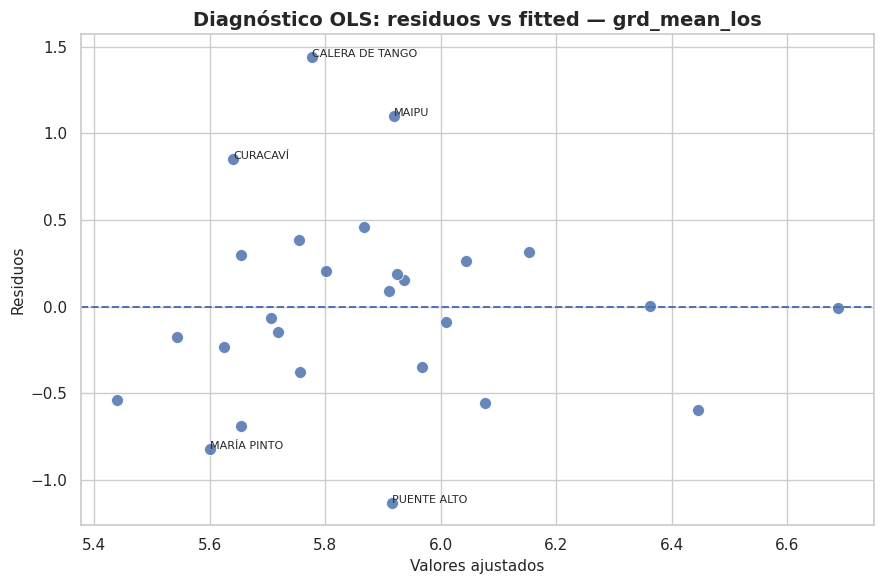

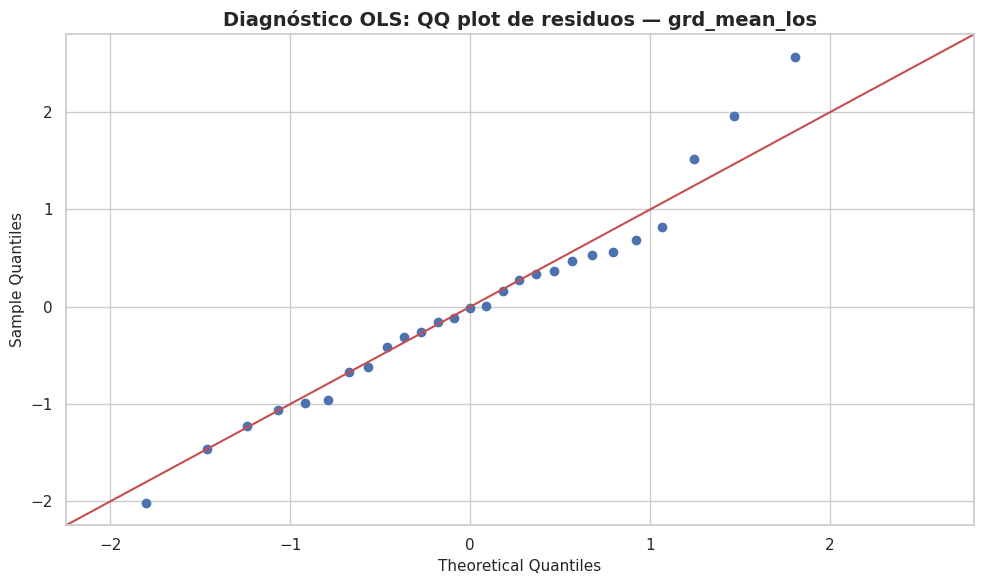

### Resumen diagnóstico OLS

,n_obs,residual_mean,residual_sd,shapiro_p_value,breusch_pagan_lm,breusch_pagan_p_value
0,27,-8.223874e-16,0.571761,0.717481,3.085182,0.543673


### Comunas con mayores residuos absolutos en OLS

,codigo_comuna,nombre_comuna,grd_mean_los,fitted,residual,abs_residual
34,13403,CALERA DE TANGO,7.220000,5.777734,1.442266,1.442266
28,13201,PUENTE ALTO,4.784390,5.915663,-1.131273,1.131273
16,13119,MAIPU,7.020000,5.919355,1.100645,1.100645
38,13503,CURACAVÍ,6.490000,5.640596,0.849404,0.849404
39,13504,MARÍA PINTO,4.780000,5.599999,-0.819999,0.819999
27,13131,SAN RAMÓN,4.966448,5.653722,-0.687274,0.687274
19,13123,PROVIDENCIA,5.850000,6.444573,-0.594573,0.594573
15,13118,MACUL,5.520947,6.075818,-0.554871,0.554871
40,13505,SAN PEDRO,4.900369,5.439075,-0.538706,0.538706
23,13127,RECOLETA,6.329066,5.866913,0.462153,0.462153



**Comentario Parte 4.**
El modelo OLS para `grd_mean_los` fue estimado con **27 comunas** y covariables estandarizadas: `['pct_foreign', 'mean_schooling_total', 'pct_unemployed', 'dependency_ratio']`.
El R² ajustado fue **0.051**, lo que resume la proporción de variación comunal explicada ajustando por el número de covariables.
Los errores robustos HC3 se reportan como complemento porque, en análisis ecológico comunal, la heterocedasticidad es plausible.

Los diagnósticos gráficos permiten revisar si los residuos presentan patrones sistemáticos. Si el gráfico residuos vs fitted muestra abanico o curvatura, o si el QQ plot se aleja fuertemente de la línea, el modelo lineal debe interpretarse con cautela. Este resultado sigue siendo ecológico y descriptivo, no causal individual.


In [12]:
# ============================================================
# PARTE 4: REGRESIÓN DE OUTCOME CONTINUO GRD Y DIAGNÓSTICOS
# ============================================================

mostrar_titulo_fern("## Parte 4 — Regresión de outcome continuo GRD")

# ------------------------------------------------------------
# 4.1 Selección flexible del outcome continuo
# ------------------------------------------------------------

def resolver_outcome_continuo_grd_fern(df_fern):
    """
    Selecciona un outcome continuo asociado a GRD.
    Prioriza indicadores clínicos promedio si existen.
    Si no existen, usa grd_rate_per_10k como outcome continuo comunal de respaldo.
    """
    candidatos_prioritarios_fern = [
        "grd_mean_los",
        "mean_los",
        "avg_los",
        "average_los",
        "grd_mean_severity",
        "mean_severity",
        "avg_severity",
        "grd_mortality_rate",
        "mortality_rate",
        "tasa_mortalidad",
        "mortalidad"
    ]

    for col_fern in candidatos_prioritarios_fern:
        if col_fern in df_fern.columns:
            serie_fern = pd.to_numeric(df_fern[col_fern], errors="coerce")
            if serie_fern.notna().sum() >= 8 and serie_fern.nunique(dropna=True) > 1:
                return col_fern, "outcome_continuo_grd_directo"

    patrones_fern = [
        r"grd.*mean.*los",
        r"mean.*los",
        r"avg.*los",
        r"los",
        r"grd.*severity",
        r"severity",
        r"mortality",
        r"mortalidad"
    ]

    for patron_fern in patrones_fern:
        for col_fern in df_fern.columns:
            if re.search(patron_fern, col_fern, flags=re.IGNORECASE):
                serie_fern = pd.to_numeric(df_fern[col_fern], errors="coerce")
                if serie_fern.notna().sum() >= 8 and serie_fern.nunique(dropna=True) > 1:
                    return col_fern, "outcome_continuo_grd_detectado_por_patron"

    if "grd_rate_per_10k" in df_fern.columns:
        serie_fern = pd.to_numeric(df_fern["grd_rate_per_10k"], errors="coerce")
        if serie_fern.notna().sum() >= 8 and serie_fern.nunique(dropna=True) > 1:
            return "grd_rate_per_10k", "outcome_continuo_comunal_de_respaldo"

    return None, "sin_outcome_continuo_disponible"


outcome_continuo_fern, tipo_outcome_continuo_fern = resolver_outcome_continuo_grd_fern(df_analitica_rm_fern)

if outcome_continuo_fern is None:
    raise ValueError(
        "No se encontró ningún outcome continuo válido para OLS. "
        "Revisa si existen columnas tipo grd_mean_los, grd_mean_severity, mortality_rate o grd_rate_per_10k."
    )

mostrar_titulo_fern("### Outcome continuo seleccionado")

display(pd.DataFrame([{
    "outcome_continuo": outcome_continuo_fern,
    "tipo_outcome": tipo_outcome_continuo_fern
}]))

if tipo_outcome_continuo_fern == "outcome_continuo_comunal_de_respaldo":
    texto_outcome_continuo_fern = f"""
**Selección del outcome.**
No se detectó una columna clínica continua directa como estadía promedio, severidad promedio o mortalidad.
Por eso se usa `{outcome_continuo_fern}` como outcome continuo comunal de respaldo. Esta variable es una tasa sanitaria por 10.000 habitantes y permite ajustar un modelo lineal descriptivo a nivel comunal.
"""
else:
    texto_outcome_continuo_fern = f"""
**Selección del outcome.**
Se selecciona `{outcome_continuo_fern}` porque representa una dimensión continua asociada a GRD a nivel comunal.
A diferencia de los conteos ENO y GRD, este outcome no se modela como frecuencia de eventos con offset, sino como variable continua mediante OLS.
"""

display(Markdown(texto_outcome_continuo_fern))

# ------------------------------------------------------------
# 4.2 Preparación de base OLS
# ------------------------------------------------------------

df_ols_base_fern = df_analitica_rm_fern.copy()

for col_fern in [outcome_continuo_fern] + covariables_modelo_fern:
    if col_fern in df_ols_base_fern.columns:
        df_ols_base_fern[col_fern] = pd.to_numeric(df_ols_base_fern[col_fern], errors="coerce")

cov_ols_candidatas_fern = covariables_modelo_fern.copy()

cov_ols_validas_fern = []

for cov_fern in cov_ols_candidatas_fern:
    if cov_fern in df_ols_base_fern.columns:
        serie_fern = pd.to_numeric(df_ols_base_fern[cov_fern], errors="coerce")
        if serie_fern.notna().sum() >= 8 and serie_fern.nunique(dropna=True) > 1:
            cov_ols_validas_fern.append(cov_fern)

datos_ols_original_fern = df_ols_base_fern[
    ["codigo_comuna", "nombre_comuna", outcome_continuo_fern] + cov_ols_validas_fern
].copy()

datos_ols_original_fern = datos_ols_original_fern.replace([np.inf, -np.inf], np.nan)

# Selección progresiva de covariables para evitar perder demasiado N.
cov_ols_fern = []

for cov_fern in cov_ols_validas_fern:
    candidatas_fern = cov_ols_fern + [cov_fern]
    tmp_fern = datos_ols_original_fern.dropna(subset=[outcome_continuo_fern] + candidatas_fern).copy()

    if len(tmp_fern) >= max(12, len(candidatas_fern) + 8):
        cov_ols_fern.append(cov_fern)

if len(cov_ols_fern) == 0:
    raise ValueError(
        "No quedaron covariables válidas para OLS con N suficiente. "
        "Revisa missing en covariables_modelo_fern."
    )

datos_ols_original_fern = datos_ols_original_fern.dropna(
    subset=[outcome_continuo_fern] + cov_ols_fern
).copy()

if len(datos_ols_original_fern) <= len(cov_ols_fern) + 2:
    raise ValueError(
        f"N insuficiente para OLS. N={len(datos_ols_original_fern)}, k={len(cov_ols_fern)}."
    )

mostrar_titulo_fern("### Disponibilidad para OLS")

display(pd.DataFrame([{
    "outcome": outcome_continuo_fern,
    "n_modelable": len(datos_ols_original_fern),
    "covariables": cov_ols_fern
}]))

# ------------------------------------------------------------
# 4.3 Ajuste del modelo OLS
# ------------------------------------------------------------

datos_ols_modelo_fern, medias_ols_fern, desvios_ols_fern = estandarizar_covariables_modelo_fern(
    datos_ols_original_fern,
    cov_ols_fern
)

y_ols_fern = datos_ols_modelo_fern[outcome_continuo_fern].astype(float)
X_ols_fern = sm.add_constant(datos_ols_modelo_fern[cov_ols_fern].astype(float), has_constant="add")

modelo_ols_fern = sm.OLS(y_ols_fern, X_ols_fern)
resultado_ols_fern = modelo_ols_fern.fit()

# Modelo con errores robustos HC3 como complemento profesional.
resultado_ols_robusto_fern = resultado_ols_fern.get_robustcov_results(cov_type="HC3")

tabla_ols_fern = tabla_coeficientes_fern(resultado_ols_fern)

tabla_ols_robusta_fern = pd.DataFrame({
    "coef": resultado_ols_robusto_fern.params,
    "std_error_robust_HC3": resultado_ols_robusto_fern.bse,
    "t_robust_HC3": resultado_ols_robusto_fern.tvalues,
    "p_value_robust_HC3": resultado_ols_robusto_fern.pvalues
}, index=resultado_ols_fern.params.index)

mostrar_titulo_fern("### OLS — Coefficient table")

display(tabla_ols_fern)

mostrar_titulo_fern("### OLS — Errores robustos HC3")

display(tabla_ols_robusta_fern)

mostrar_titulo_fern("### OLS — Métricas de ajuste")

display(pd.DataFrame([{
    "outcome": outcome_continuo_fern,
    "n_obs": int(resultado_ols_fern.nobs),
    "r2": resultado_ols_fern.rsquared,
    "r2_adj": resultado_ols_fern.rsquared_adj,
    "AIC": resultado_ols_fern.aic,
    "BIC": resultado_ols_fern.bic
}]))

# ------------------------------------------------------------
# 4.4 Diagnósticos del modelo OLS
# ------------------------------------------------------------

datos_ols_diagnostico_fern = datos_ols_original_fern.copy()
datos_ols_diagnostico_fern["fitted"] = resultado_ols_fern.fittedvalues
datos_ols_diagnostico_fern["residual"] = resultado_ols_fern.resid
datos_ols_diagnostico_fern["abs_residual"] = datos_ols_diagnostico_fern["residual"].abs()

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=datos_ols_diagnostico_fern,
    x="fitted",
    y="residual",
    s=75,
    alpha=0.85
)

plt.axhline(0, linestyle="--", linewidth=1.4)
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title(f"Diagnóstico OLS: residuos vs fitted — {outcome_continuo_fern}", weight="bold")

for _, fila_fern in datos_ols_diagnostico_fern.sort_values("abs_residual", ascending=False).head(5).iterrows():
    plt.text(
        fila_fern["fitted"],
        fila_fern["residual"],
        str(fila_fern["nombre_comuna"])[:18],
        fontsize=8
    )

plt.tight_layout()

RUTA_FIG_OLS_RESID_FERN = RUTA_OUTPUT_FERN / "fig_3_3_ols_residuals_vs_fitted.png"
plt.savefig(RUTA_FIG_OLS_RESID_FERN, dpi=300, bbox_inches="tight")
plt.show()

fig_qq_fern = sm.qqplot(resultado_ols_fern.resid, line="45", fit=True)
plt.title(f"Diagnóstico OLS: QQ plot de residuos — {outcome_continuo_fern}", weight="bold")
plt.tight_layout()

RUTA_FIG_OLS_QQ_FERN = RUTA_OUTPUT_FERN / "fig_3_3_ols_qqplot.png"
plt.savefig(RUTA_FIG_OLS_QQ_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4.5 Diagnósticos numéricos
# ------------------------------------------------------------

shapiro_p_fern = np.nan

if 3 <= len(resultado_ols_fern.resid) <= 5000:
    shapiro_p_fern = stats.shapiro(resultado_ols_fern.resid).pvalue

try:
    bp_test_fern = sm.stats.diagnostic.het_breuschpagan(
        resultado_ols_fern.resid,
        resultado_ols_fern.model.exog
    )

    bp_lm_fern = bp_test_fern[0]
    bp_pvalue_fern = bp_test_fern[1]

except Exception:
    bp_lm_fern = np.nan
    bp_pvalue_fern = np.nan

df_diagnostico_ols_fern = pd.DataFrame([{
    "n_obs": int(resultado_ols_fern.nobs),
    "residual_mean": float(np.mean(resultado_ols_fern.resid)),
    "residual_sd": float(np.std(resultado_ols_fern.resid, ddof=1)),
    "shapiro_p_value": shapiro_p_fern,
    "breusch_pagan_lm": bp_lm_fern,
    "breusch_pagan_p_value": bp_pvalue_fern
}])

mostrar_titulo_fern("### Resumen diagnóstico OLS")

display(df_diagnostico_ols_fern)

# ------------------------------------------------------------
# 4.6 Comunas con mayores residuos
# ------------------------------------------------------------

mostrar_titulo_fern("### Comunas con mayores residuos absolutos en OLS")

display(
    datos_ols_diagnostico_fern[
        [
            "codigo_comuna",
            "nombre_comuna",
            outcome_continuo_fern,
            "fitted",
            "residual",
            "abs_residual"
        ]
    ]
    .sort_values("abs_residual", ascending=False)
    .head(10)
)

texto_parte4_fern = f"""
**Comentario Parte 4.**
El modelo OLS para `{outcome_continuo_fern}` fue estimado con **{int(resultado_ols_fern.nobs)} comunas** y covariables estandarizadas: `{cov_ols_fern}`.
El R² ajustado fue **{resultado_ols_fern.rsquared_adj:.3f}**, lo que resume la proporción de variación comunal explicada ajustando por el número de covariables.
Los errores robustos HC3 se reportan como complemento porque, en análisis ecológico comunal, la heterocedasticidad es plausible.

Los diagnósticos gráficos permiten revisar si los residuos presentan patrones sistemáticos. Si el gráfico residuos vs fitted muestra abanico o curvatura, o si el QQ plot se aleja fuertemente de la línea, el modelo lineal debe interpretarse con cautela. Este resultado sigue siendo ecológico y descriptivo, no causal individual.
"""

display(Markdown(texto_parte4_fern))

**Resultados del modelo OLS para longitud de estadía promedio**

El outcome continuo usado fue `grd_mean_los`, con 27 comunas disponibles. Las covariables son las mismas que en los modelos de conteo.

El R² ajustado fue **0.051**, lo que indica que estas variables explican cerca de un 5% de la variación en la estadía promedio entre comunas. No es raro, porque la duración de estadía depende más del tipo de diagnóstico, severidad, disponibilidad de camas y protocolos clínicos, cosas que no están en el Censo.

Ningún coeficiente resulta significativo, ni con errores estándar normales ni con robustos HC3. La constante 5.88 representa la estadía promedio esperada cuando las covariables están en su valor medio, es decir, cerca de 6 días.

Diagnósticos del modelo:

* Shapiro-Wilk p = 0.718, no se rechaza normalidad de residuos
* Breusch-Pagan p = 0.544, no hay evidencia de heterocedasticidad
* El gráfico residuos vs fitted no muestra patrones claros

Las comunas con mayores residuos fueron **Calera de Tango** con +1.44, **Puente Alto** con -1.13 y **Curacaví** con +0.85. En el caso de Curacaví, puede explicarse porque, al ser una comuna más rural, sus egresos tienden a estar asociados a casos más complejos derivados desde centros de menor complejidad.


---
## Parte 5 — Falacia ecológica e interpretación sustantiva

Esta es quizás la parte más importante conceptualmente. El análisis ecológico tiene una limitación fundamental que se debe discutir explícitamente: la falacia ecológica.

La falacia ecológica ocurre cuando se intenta inferir comportamientos o riesgos individuales a partir de datos agregados. Por ejemplo: si una comuna con mayor porcentaje de extranjeros tiene más notificaciones ENO, eso no significa que los extranjeros sean quienes generan más notificaciones. Puede deberse a muchos factores confundentes a nivel comunal como el mayor acceso a servicios, composición etaria, hacinamiento, tipo de empleo, etc.

En esta parte presentamos:
1. Una tabla comparando la lectura correcta vs la incorrecta de los coeficientes
2. Un texto desarrollado que explica la falacia aplicada a nuestros resultados específicos
3. Una discusión complementaria para el modelo GRD y el OLS

In [13]:
# ============================================================
# PARTE 5: FALACIA ECOLÓGICA E INTERPRETACIÓN SUSTANTIVA
# ============================================================

mostrar_titulo_fern("## Parte 5 — Falacia ecológica e interpretación sustantiva")

# ------------------------------------------------------------
# 5.1 Selección del efecto principal del modelo ENO
# ------------------------------------------------------------

def formatear_valor_fern(valor_fern, decimales_fern=3):
    """
    Formatea valores numéricos de forma segura.
    """
    if pd.isna(valor_fern):
        return "no disponible"

    return f"{valor_fern:.{decimales_fern}f}"


def obtener_efecto_principal_irr_fern(irr_fern):
    """
    Selecciona la covariable con mayor distancia respecto de IRR = 1.
    Excluye el intercepto.
    """
    if not isinstance(irr_fern, pd.DataFrame):
        return None, np.nan, np.nan, np.nan, np.nan

    if len(irr_fern) == 0:
        return None, np.nan, np.nan, np.nan, np.nan

    tabla_fern = irr_fern.drop(index="const", errors="ignore").copy()

    if len(tabla_fern) == 0:
        return None, np.nan, np.nan, np.nan, np.nan

    if "IRR" not in tabla_fern.columns:
        return None, np.nan, np.nan, np.nan, np.nan

    tabla_fern["distancia_a_1"] = (tabla_fern["IRR"] - 1).abs()
    tabla_fern = tabla_fern.sort_values("distancia_a_1", ascending=False)

    variable_fern = tabla_fern.index[0]
    irr_fern_valor = tabla_fern.loc[variable_fern, "IRR"]
    irr_low_fern = tabla_fern.loc[variable_fern, "IRR_ci_low"] if "IRR_ci_low" in tabla_fern.columns else np.nan
    irr_high_fern = tabla_fern.loc[variable_fern, "IRR_ci_high"] if "IRR_ci_high" in tabla_fern.columns else np.nan
    p_value_fern = tabla_fern.loc[variable_fern, "p_value"] if "p_value" in tabla_fern.columns else np.nan

    return variable_fern, irr_fern_valor, irr_low_fern, irr_high_fern, p_value_fern


variable_efecto_eno_fern, irr_efecto_eno_fern, irr_efecto_low_fern, irr_efecto_high_fern, p_efecto_eno_fern = obtener_efecto_principal_irr_fern(
    irr_eno_principal_fern
)

if variable_efecto_eno_fern is None:
    variable_efecto_eno_fern = "pct_foreign"

mostrar_titulo_fern("### Efecto principal seleccionado para discutir falacia ecológica")

display(pd.DataFrame([{
    "modelo_eno_principal": familia_eno_principal_fern,
    "variable_discutida": variable_efecto_eno_fern,
    "IRR": irr_efecto_eno_fern,
    "IRR_ci_low": irr_efecto_low_fern,
    "IRR_ci_high": irr_efecto_high_fern,
    "p_value": p_efecto_eno_fern,
    "n_modelo_eno": len(datos_eno_principal_original_fern)
}]))

# ------------------------------------------------------------
# 5.2 Tabla de lectura correcta vs lectura incorrecta
# ------------------------------------------------------------

df_falacia_comparacion_fern = pd.DataFrame([
    {
        "aspecto": "Unidad de análisis",
        "lectura_correcta": "La unidad observada es la comuna.",
        "lectura_incorrecta": "Tratar cada coeficiente como si proviniera de individuos."
    },
    {
        "aspecto": "Interpretación del IRR",
        "lectura_correcta": "El IRR compara tasas esperadas entre comunas con distinta composición agregada.",
        "lectura_incorrecta": "Afirmar que una persona individual tiene ese mismo cambio relativo de riesgo."
    },
    {
        "aspecto": "Uso sanitario",
        "lectura_correcta": "Sirve para priorizar territorios, vigilancia y planificación comunal.",
        "lectura_incorrecta": "Usarlo para atribuir causalidad clínica o conductual a personas."
    },
    {
        "aspecto": "Limitación principal",
        "lectura_correcta": "Puede haber confusión por oferta sanitaria, movilidad, derivaciones y subregistro.",
        "lectura_incorrecta": "Asumir que el modelo controla todos los factores relevantes."
    }
])

mostrar_titulo_fern("### Lectura correcta vs lectura incorrecta")

display(df_falacia_comparacion_fern)

# ------------------------------------------------------------
# 5.3 Texto desarrollado sobre falacia ecológica
# ------------------------------------------------------------

texto_falacia_fern = f"""
### Discusión: falacia ecológica

La unidad de observación de este análisis es la **comuna**, no la persona. Cada fila de la tabla analítica representa un territorio agregado de la Región Metropolitana construido a partir de información censal, notificaciones ENO y egresos GRD. Por lo tanto, los coeficientes estimados describen asociaciones entre características promedio o proporciones comunales y resultados sanitarios agregados. Esto es distinto a una asociación individual, donde se observaría directamente si una persona con determinada característica presenta mayor o menor riesgo de un evento sanitario.

El modelo principal para ENO fue **{familia_eno_principal_fern}**, estimado con **{len(datos_eno_principal_original_fern)} comunas** y usando `log_pop_total` como offset poblacional. La variable seleccionada para ilustrar la interpretación fue **{variable_efecto_eno_fern}**, con un IRR aproximado de **{formatear_valor_fern(irr_efecto_eno_fern, 3)}**, intervalo aproximado **[{formatear_valor_fern(irr_efecto_low_fern, 3)}, {formatear_valor_fern(irr_efecto_high_fern, 3)}]** y p-value **{formatear_valor_fern(p_efecto_eno_fern, 4)}**. La lectura ecológica correcta es que, manteniendo constantes las demás covariables incluidas, comunas con mayor valor estandarizado de **{variable_efecto_eno_fern}** presentan una tasa esperada de notificaciones ENO multiplicada aproximadamente por ese IRR. Como las covariables fueron estandarizadas, el cambio se interpreta por un aumento de una desviación estándar en la covariable.

La lectura incorrecta sería afirmar que una persona individual que posee esa característica tiene necesariamente mayor o menor probabilidad de ser notificada. Esa afirmación sería una **falacia ecológica**, porque el modelo no observa exposición individual, diagnóstico individual, trayectoria clínica, aseguramiento de salud, movilidad diaria ni acceso individual al sistema. Por ejemplo, si una comuna con mayor porcentaje de población extranjera presenta mayor tasa ENO, eso no implica que las personas extranjeras sean quienes generan directamente esa tasa. La diferencia puede deberse a composición territorial, concentración de servicios, patrones de consulta, edad, hacinamiento, movilidad, subregistro diferencial o capacidad de detección.

El resultado ecológico sí puede ser útil para planificación sanitaria. Una comuna con mayor tasa predicha o con residuo positivo puede ser priorizada para vigilancia, revisión de cobertura, campañas preventivas o análisis territorial más detallado. Sin embargo, la utilidad está en identificar **territorios** que se comportan distinto a comunas comparables, no en asignar causalidad a individuos específicos. En este sentido, el modelo funciona como herramienta de priorización comunal y generación de hipótesis.

También existen amenazas metodológicas importantes. Primero, puede haber variables omitidas relevantes, como oferta hospitalaria, presencia de centros de referencia, disponibilidad de atención primaria, aseguramiento, ingreso, movilidad intercomunal y derivaciones. Segundo, puede existir autocorrelación espacial, porque comunas cercanas comparten infraestructura, redes urbanas y dinámicas socioeconómicas. Tercero, los registros ENO y GRD pueden depender de la calidad del registro y no solo de la carga real de enfermedad. Por estas razones, los resultados deben presentarse como asociaciones ecológicas descriptivas y no como evidencia causal individual.
"""

display(Markdown(texto_falacia_fern))

# ------------------------------------------------------------
# 5.4 Interpretación complementaria del modelo GRD y OLS
# ------------------------------------------------------------

if "efectos_grd_fern" in globals() and isinstance(efectos_grd_fern, pd.DataFrame) and len(efectos_grd_fern) > 0:
    variable_grd_discusion_fern = efectos_grd_fern.index[0]
    irr_grd_discusion_fern = efectos_grd_fern.iloc[0]["IRR"]
else:
    variable_grd_discusion_fern = "no disponible"
    irr_grd_discusion_fern = np.nan

texto_falacia_grd_ols_fern = f"""
### Complemento GRD y outcome continuo

En el modelo GRD, la variable con mayor distancia respecto de IRR = 1 fue **{variable_grd_discusion_fern}**, con IRR aproximado de **{formatear_valor_fern(irr_grd_discusion_fern, 3)}**. La interpretación sigue la misma lógica: se trata de una asociación entre comunas, no entre individuos. Una comuna con mayor escolaridad promedio, desempleo o dependencia demográfica puede tener una tasa esperada de egresos distinta, pero eso no prueba que una persona con esa característica tenga directamente menor o mayor riesgo de hospitalización.

En el modelo OLS para **{outcome_continuo_fern}**, el R² ajustado fue **{resultado_ols_fern.rsquared_adj:.3f}**. Este valor indica que las covariables censales incluidas explican una parte limitada de la variación comunal del outcome continuo GRD. Este resultado es sustantivamente razonable: la duración promedio de estadía u otro indicador continuo GRD probablemente depende de severidad clínica, oferta hospitalaria, prácticas de derivación, tipo de establecimiento y composición diagnóstica, variables que no están completamente representadas en la base censal.
"""

display(Markdown(texto_falacia_grd_ols_fern))

# ------------------------------------------------------------
# 5.5 Exportación de texto de Parte 5
# ------------------------------------------------------------

RUTA_TEXTO_FALACIA_FERN = RUTA_OUTPUT_FERN / "tarea3_parte5_falacia_ecologica.md"

with open(RUTA_TEXTO_FALACIA_FERN, "w", encoding="utf-8") as archivo_fern:
    archivo_fern.write("# Parte 5 — Falacia ecológica\n\n")
    archivo_fern.write(texto_falacia_fern)
    archivo_fern.write("\n\n")
    archivo_fern.write(texto_falacia_grd_ols_fern)

print("Texto de falacia ecológica exportado en:", RUTA_TEXTO_FALACIA_FERN)

## Parte 5 — Falacia ecológica e interpretación sustantiva

### Efecto principal seleccionado para discutir falacia ecológica

,modelo_eno_principal,variable_discutida,IRR,IRR_ci_low,IRR_ci_high,p_value,n_modelo_eno
0,Negative Binomial,pct_foreign,1.581393,1.281922,1.950823,0.000019,36


### Lectura correcta vs lectura incorrecta

,aspecto,lectura_correcta,lectura_incorrecta
0,Unidad de análisis,La unidad observada es la comuna.,Tratar cada coeficiente como si proviniera de ...
1,Interpretación del IRR,El IRR compara tasas esperadas entre comunas c...,Afirmar que una persona individual tiene ese m...
2,Uso sanitario,"Sirve para priorizar territorios, vigilancia y...",Usarlo para atribuir causalidad clínica o cond...
3,Limitación principal,"Puede haber confusión por oferta sanitaria, mo...",Asumir que el modelo controla todos los factor...



### Discusión: falacia ecológica

La unidad de observación de este análisis es la **comuna**, no la persona. Cada fila de la tabla analítica representa un territorio agregado de la Región Metropolitana construido a partir de información censal, notificaciones ENO y egresos GRD. Por lo tanto, los coeficientes estimados describen asociaciones entre características promedio o proporciones comunales y resultados sanitarios agregados. Esto es distinto a una asociación individual, donde se observaría directamente si una persona con determinada característica presenta mayor o menor riesgo de un evento sanitario.

El modelo principal para ENO fue **Negative Binomial**, estimado con **36 comunas** y usando `log_pop_total` como offset poblacional. La variable seleccionada para ilustrar la interpretación fue **pct_foreign**, con un IRR aproximado de **1.581**, intervalo aproximado **[1.282, 1.951]** y p-value **0.0000**. La lectura ecológica correcta es que, manteniendo constantes las demás covariables incluidas, comunas con mayor valor estandarizado de **pct_foreign** presentan una tasa esperada de notificaciones ENO multiplicada aproximadamente por ese IRR. Como las covariables fueron estandarizadas, el cambio se interpreta por un aumento de una desviación estándar en la covariable.

La lectura incorrecta sería afirmar que una persona individual que posee esa característica tiene necesariamente mayor o menor probabilidad de ser notificada. Esa afirmación sería una **falacia ecológica**, porque el modelo no observa exposición individual, diagnóstico individual, trayectoria clínica, aseguramiento de salud, movilidad diaria ni acceso individual al sistema. Por ejemplo, si una comuna con mayor porcentaje de población extranjera presenta mayor tasa ENO, eso no implica que las personas extranjeras sean quienes generan directamente esa tasa. La diferencia puede deberse a composición territorial, concentración de servicios, patrones de consulta, edad, hacinamiento, movilidad, subregistro diferencial o capacidad de detección.

El resultado ecológico sí puede ser útil para planificación sanitaria. Una comuna con mayor tasa predicha o con residuo positivo puede ser priorizada para vigilancia, revisión de cobertura, campañas preventivas o análisis territorial más detallado. Sin embargo, la utilidad está en identificar **territorios** que se comportan distinto a comunas comparables, no en asignar causalidad a individuos específicos. En este sentido, el modelo funciona como herramienta de priorización comunal y generación de hipótesis.

También existen amenazas metodológicas importantes. Primero, puede haber variables omitidas relevantes, como oferta hospitalaria, presencia de centros de referencia, disponibilidad de atención primaria, aseguramiento, ingreso, movilidad intercomunal y derivaciones. Segundo, puede existir autocorrelación espacial, porque comunas cercanas comparten infraestructura, redes urbanas y dinámicas socioeconómicas. Tercero, los registros ENO y GRD pueden depender de la calidad del registro y no solo de la carga real de enfermedad. Por estas razones, los resultados deben presentarse como asociaciones ecológicas descriptivas y no como evidencia causal individual.



### Complemento GRD y outcome continuo

En el modelo GRD, la variable con mayor distancia respecto de IRR = 1 fue **mean_schooling_total**, con IRR aproximado de **0.732**. La interpretación sigue la misma lógica: se trata de una asociación entre comunas, no entre individuos. Una comuna con mayor escolaridad promedio, desempleo o dependencia demográfica puede tener una tasa esperada de egresos distinta, pero eso no prueba que una persona con esa característica tenga directamente menor o mayor riesgo de hospitalización.

En el modelo OLS para **grd_mean_los**, el R² ajustado fue **0.051**. Este valor indica que las covariables censales incluidas explican una parte limitada de la variación comunal del outcome continuo GRD. Este resultado es sustantivamente razonable: la duración promedio de estadía u otro indicador continuo GRD probablemente depende de severidad clínica, oferta hospitalaria, prácticas de derivación, tipo de establecimiento y composición diagnóstica, variables que no están completamente representadas en la base censal.


Texto de falacia ecológica exportado en: /content/drive/MyDrive/ColabNotebooks/output/tarea3_parte5_falacia_ecologica.md


**Sobre la falacia ecológica aplicada a nuestros resultados**

El resultado más relevante es el IRR de `pct_foreign` en el modelo ENO: 1.581, con IC 95% [1.282, 1.951] y p = 0.00002.
La interpretación correcta es que comunas con mayor porcentaje de población extranjera tienden a tener tasas ENO más altas, pero eso no implica que sean los extranjeros quienes generan esas notificaciones.

Hay varias explicaciones posibles por ejemplo:

* comunas con más extranjeros pueden tener mejor acceso a atención primaria
* mayor densidad o hacinamiento que facilita la transmisión
* mayor vigilancia o capacidad de diagnóstico

Para saber si la relación es a nivel individual se necesitarían datos de quién fue notificado, cosa que no está en este análisis ecológico.

En el modelo GRD no hay variables significativas, lo que igual es un resultado relevante. Indica que la composición censal de la comuna no explica bien los egresos hospitalarios, lo que es consistente con que estos dependen más de factores del sistema de salud que de la demografía.


---
## Parte 6 — Visualización espacial del modelo

Los mapas permiten ver territorialmente dónde el modelo predice mayor carga sanitaria y dónde las predicciones se alejan de lo observado. Esta parte produce tres tipos de visualizaciones:

**Mapa de tasa ENO predicha:** muestra la tasa de notificaciones que el modelo espera para cada comuna según su composición censal. Las comunas en gris no tienen datos completos para entrar al modelo.

**Mapa de residuos Pearson:** muestra la diferencia entre lo observado y lo predicho, estandarizada por la varianza del modelo. Las comunas en rojo observaron más notificaciones que las esperadas; las azules observaron menos. Estos residuos identifican territorios que el modelo no captura bien.

**Gráfico observado vs predicho:** compara directamente la tasa observada y predicha para cada comuna modelada.

**Coefficient plot (forest plot):** visualiza los IRR con sus intervalos de confianza al 95%. Permite identificar rápidamente qué covariables tienen efectos más fuertes y cuáles cruzan el valor de referencia (IRR = 1).

## Parte 6 — Visualización espacial del modelo

### Shapefile filtrado a Región Metropolitana

,n_comunas_shapefile_total,n_comunas_rm,crs
0,345,52,EPSG:5360


### Comunas RM con predicción del modelo ENO

,codigo_comuna,nombre_mapa_fern,eno_total,pop_total,obs_rate_eno_per_10k,pred_rate_eno_per_10k,pearson_resid_eno
50,13505,SAN PEDRO,731.0,11108.0,658.084264,135.128432,7.200426
3,13123,PROVIDENCIA,1455.0,143974.0,101.059914,46.741171,2.181806
49,13114,LAS CONDES,2123.0,292739.0,72.521939,49.289997,0.886136
35,13104,CONCHALÍ,1134.0,121587.0,93.266550,68.431673,0.681692
12,13105,EL BOSQUE,1212.0,155257.0,78.064113,59.068824,0.604167
11,13202,PIRQUE,136.0,29060.0,46.799725,38.046869,0.426273
31,13101,SANTIAGO,12186.0,435385.0,279.890212,229.491202,0.413319
21,13107,HUECHURABA,832.0,101808.0,81.722458,67.147893,0.407518
27,13201,PUENTE ALTO,4334.0,564477.0,76.779036,64.327947,0.364168
43,13116,LO ESPEJO,678.0,87295.0,77.667679,66.308148,0.321495


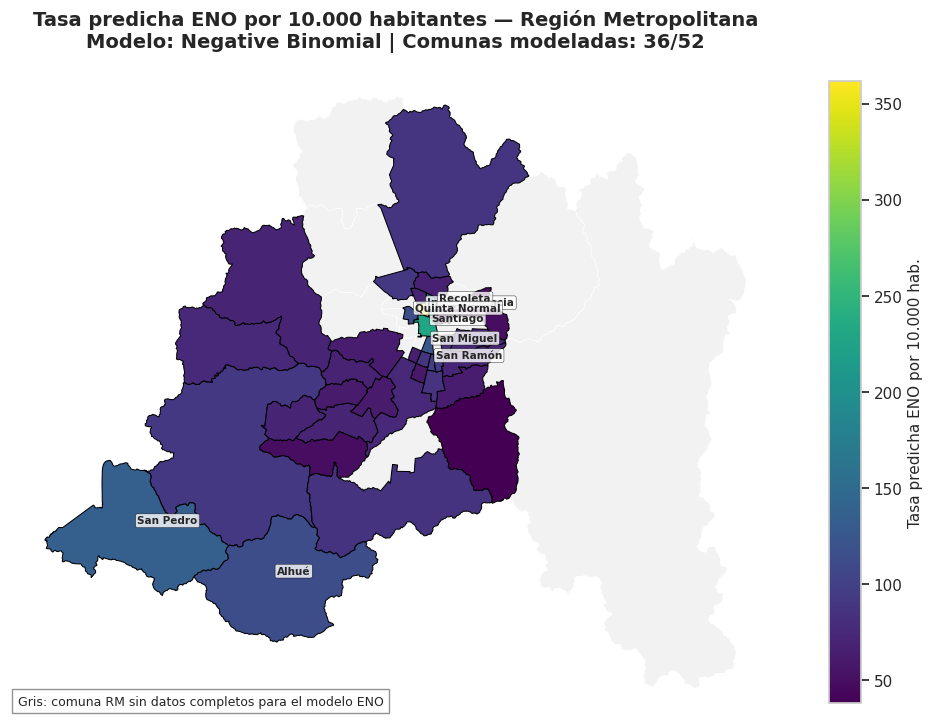

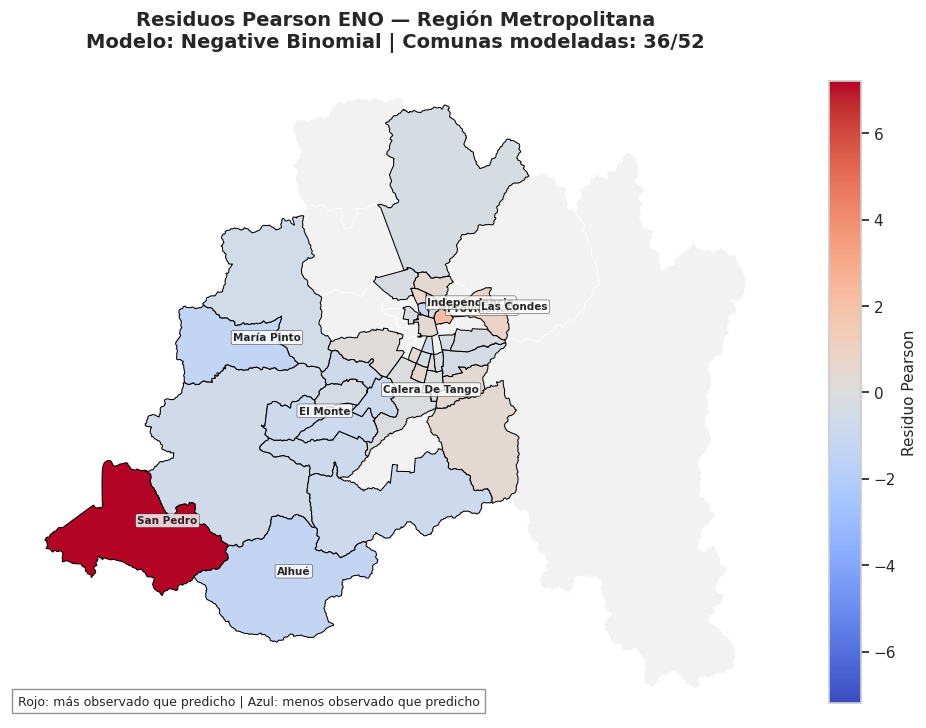

### Mayores residuos positivos

,codigo_comuna,nombre_comuna,eno_total,pop_total,obs_rate_eno_per_10k,pred_count_eno,pred_rate_eno_per_10k,pearson_resid_eno
40,13505,SAN PEDRO,731.0,11108.0,658.084264,150.100662,135.128432,7.200426
19,13123,PROVIDENCIA,1455.0,143974.0,101.059914,672.951337,46.741171,2.181806
11,13114,LAS CONDES,2123.0,292739.0,72.521939,1442.910429,49.289997,0.886136
3,13104,CONCHALÍ,1134.0,121587.0,93.266550,832.040186,68.431673,0.681692
4,13105,EL BOSQUE,1212.0,155257.0,78.064113,917.084839,59.068824,0.604167


### Mayores residuos negativos

,codigo_comuna,nombre_comuna,eno_total,pop_total,obs_rate_eno_per_10k,pred_count_eno,pred_rate_eno_per_10k,pearson_resid_eno
39,13504,MARÍA PINTO,32.0,15352.0,20.844190,113.415400,73.876628,-1.330640
37,13502,ALHUÉ,28.0,7768.0,36.045314,87.856864,113.101010,-1.257358
6,13108,INDEPENDENCIA,1642.0,116943.0,140.410285,4227.963181,361.540510,-1.150842
34,13403,CALERA DE TANGO,84.0,25491.0,32.952807,157.597069,61.824593,-0.869342
42,13602,EL MONTE,146.0,37497.0,38.936448,264.519840,70.544267,-0.837818


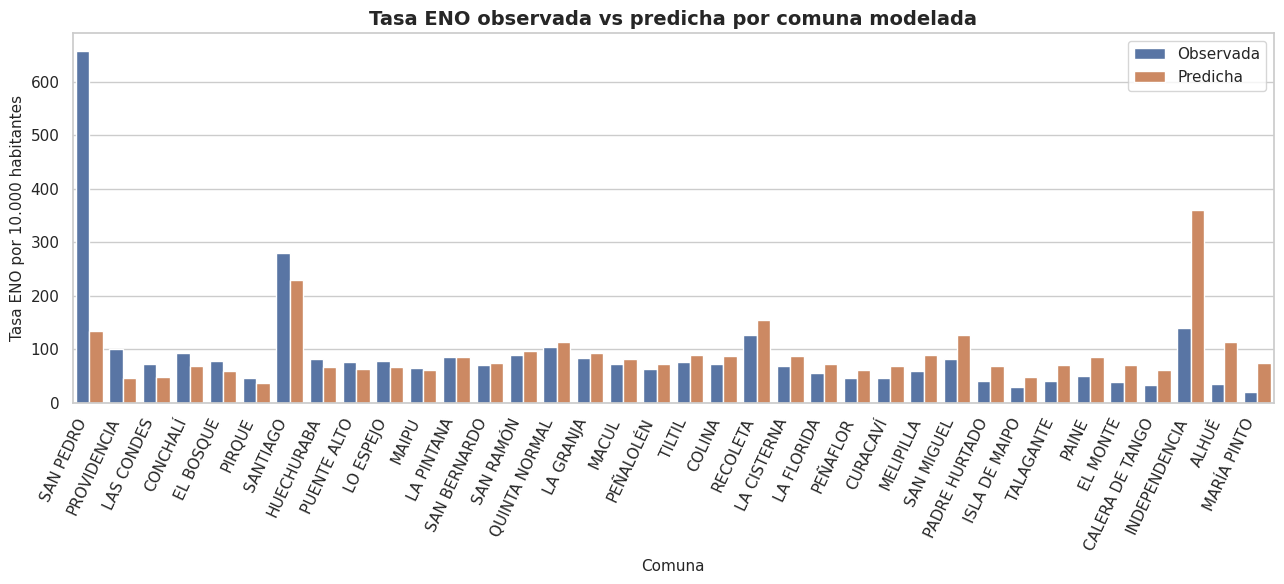

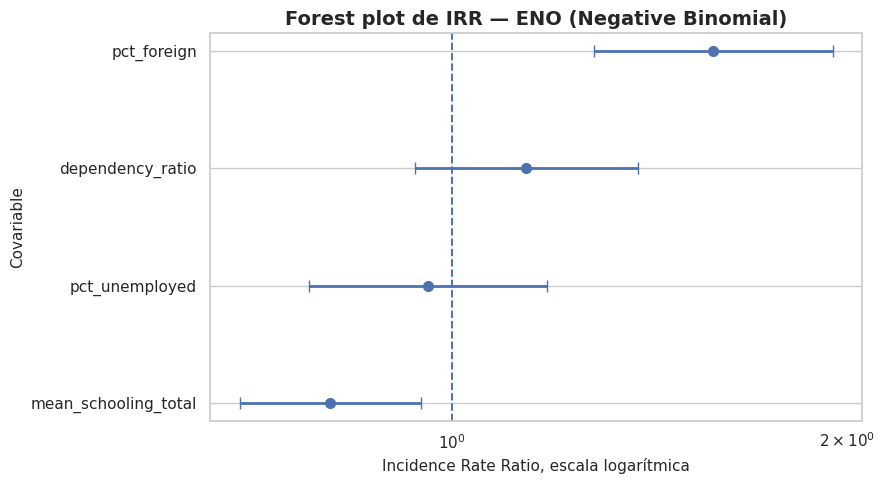

### Tabla usada en coefficient plot

,coef,std_error,z_or_t,p_value,IRR,IRR_ci_low,IRR_ci_high
mean_schooling_total,-0.214291,0.080947,-2.647312,0.008113,0.807114,0.688704,0.945881
pct_unemployed,-0.042643,0.106277,-0.401244,0.688240,0.958253,0.778067,1.180168
dependency_ratio,0.130164,0.100050,1.300988,0.193262,1.139015,0.936196,1.385774
pct_foreign,0.458306,0.107117,4.278553,0.000019,1.581393,1.281922,1.950823



**Comentario Parte 6.**
La visualización espacial usa el modelo principal ENO (**Negative Binomial**) y muestra predicciones para **36 de 52 comunas** de la Región Metropolitana. Las comunas en gris no tienen información completa para entrar al modelo ENO con las covariables seleccionadas.

La comuna con mayor residuo positivo fue **SAN PEDRO**, lo que indica que observó más notificaciones ENO que las esperadas por el modelo. La comuna con mayor residuo negativo fue **MARÍA PINTO**, lo que indica menos notificaciones observadas que las predichas. Estos residuos son útiles para identificar territorios donde las covariables censales incluidas no explican completamente la carga sanitaria observada.

El coefficient plot resume los IRR del modelo principal. La línea vertical en IRR = 1 representa ausencia de asociación. Valores sobre 1 indican asociación positiva con la tasa esperada de notificaciones, mientras que valores bajo 1 indican asociación negativa, siempre en términos ecológicos comunales y no individuales.


In [14]:
# ============================================================
# PARTE 6: VISUALIZACIÓN ESPACIAL DEL MODELO
# ============================================================

mostrar_titulo_fern("## Parte 6 — Visualización espacial del modelo")

# ------------------------------------------------------------
# 6.1 Funciones auxiliares para mapas
# ------------------------------------------------------------

def detectar_columna_codigo_shape_fern(gdf_fern):
    """
    Detecta la columna del shapefile que contiene el código comunal.
    """
    columnas_normalizadas_fern = {
        normalizar_nombre_columna_fern(c): c
        for c in gdf_fern.columns
    }

    candidatos_fern = [
        "codigo_comuna",
        "cod_comuna",
        "cut_comuna",
        "cut_com",
        "comuna"
    ]

    for candidato_fern in candidatos_fern:
        if candidato_fern in columnas_normalizadas_fern:
            return columnas_normalizadas_fern[candidato_fern]

    for col_norm_fern, col_original_fern in columnas_normalizadas_fern.items():
        if ("cod" in col_norm_fern and "com" in col_norm_fern) or ("cut" in col_norm_fern and "com" in col_norm_fern):
            return col_original_fern

    raise ValueError("No se pudo detectar columna de código comunal en el shapefile.")


def detectar_columna_nombre_shape_fern(gdf_fern):
    """
    Detecta la columna del shapefile que contiene el nombre comunal.
    """
    columnas_normalizadas_fern = {
        normalizar_nombre_columna_fern(c): c
        for c in gdf_fern.columns
    }

    candidatos_fern = [
        "nombre_comuna",
        "nom_comuna",
        "comuna",
        "nom_com",
        "nombre"
    ]

    for candidato_fern in candidatos_fern:
        if candidato_fern in columnas_normalizadas_fern:
            return columnas_normalizadas_fern[candidato_fern]

    return None


def preparar_exog_prediccion_fern(resultado_fern, datos_modelo_fern, covariables_fern):
    """
    Construye la matriz X para predecir con el mismo orden de columnas del modelo ajustado.
    """
    if len(covariables_fern) == 0:
        X_pred_fern = pd.DataFrame({"const": 1.0}, index=datos_modelo_fern.index)
    else:
        X_pred_fern = sm.add_constant(datos_modelo_fern[covariables_fern].astype(float), has_constant="add")

    exog_names_fern = list(resultado_fern.params.index)
    exog_names_fern = [x for x in exog_names_fern if x != "alpha"]

    for col_fern in exog_names_fern:
        if col_fern not in X_pred_fern.columns:
            X_pred_fern[col_fern] = 0

    X_pred_fern = X_pred_fern[exog_names_fern]

    return X_pred_fern


def predecir_conteo_modelo_fern(resultado_fern, datos_modelo_fern, covariables_fern, offset_fern="log_pop_total"):
    """
    Predice conteos esperados del modelo principal de conteo.
    Compatible con GLM Poisson, GLM Negative Binomial y NegativeBinomial discreto.
    """
    if resultado_fern is None:
        return np.repeat(np.nan, len(datos_modelo_fern))

    X_pred_fern = preparar_exog_prediccion_fern(
        resultado_fern,
        datos_modelo_fern,
        covariables_fern
    )

    try:
        pred_fern = resultado_fern.predict(
            X_pred_fern,
            offset=datos_modelo_fern[offset_fern].astype(float)
        )
    except Exception:
        pred_fern = resultado_fern.predict(X_pred_fern)

    return np.asarray(pred_fern)


def agregar_etiquetas_mapa_fern(gdf_fern, ax_fern, columna_nombre_fern, columna_valor_fern, max_etiquetas_fern=10):
    """
    Etiqueta comunas con datos disponibles, priorizando valores extremos.
    """
    gdf_labels_fern = gdf_fern.dropna(subset=[columna_valor_fern]).copy()

    if len(gdf_labels_fern) == 0:
        return

    if len(gdf_labels_fern) > max_etiquetas_fern:
        gdf_labels_fern["abs_valor_fern"] = gdf_labels_fern[columna_valor_fern].abs()
        gdf_labels_fern = gdf_labels_fern.sort_values("abs_valor_fern", ascending=False).head(max_etiquetas_fern)

    puntos_fern = gdf_labels_fern.geometry.representative_point()

    for idx_fern, punto_fern in puntos_fern.items():
        nombre_fern = str(gdf_labels_fern.loc[idx_fern, columna_nombre_fern]).title()

        ax_fern.annotate(
            text=nombre_fern,
            xy=(punto_fern.x, punto_fern.y),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=7.5,
            weight="bold",
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="black",
                alpha=0.80,
                linewidth=0.35
            )
        )


# ------------------------------------------------------------
# 6.2 Lectura del shapefile y filtro Región Metropolitana
# ------------------------------------------------------------

if not RUTA_COMUNAS_SHP_FERN.exists():
    raise FileNotFoundError(f"No existe el shapefile: {RUTA_COMUNAS_SHP_FERN}")

gdf_comunas_fern = gpd.read_file(RUTA_COMUNAS_SHP_FERN)

col_codigo_shape_fern = detectar_columna_codigo_shape_fern(gdf_comunas_fern)
col_nombre_shape_fern = detectar_columna_nombre_shape_fern(gdf_comunas_fern)

gdf_comunas_fern["codigo_comuna"] = pd.to_numeric(gdf_comunas_fern[col_codigo_shape_fern], errors="coerce")
gdf_comunas_fern = gdf_comunas_fern.dropna(subset=["codigo_comuna"]).copy()
gdf_comunas_fern["codigo_comuna"] = gdf_comunas_fern["codigo_comuna"].astype(int)

if col_nombre_shape_fern is not None:
    gdf_comunas_fern["nombre_shape_fern"] = (
        gdf_comunas_fern[col_nombre_shape_fern]
        .astype(str)
        .str.strip()
        .str.upper()
    )
else:
    gdf_comunas_fern["nombre_shape_fern"] = np.nan

# Región Metropolitana: códigos comunales 13xxx.
gdf_rm_fern = gdf_comunas_fern[
    (gdf_comunas_fern["codigo_comuna"] >= 13000)
    & (gdf_comunas_fern["codigo_comuna"] < 14000)
].copy()

if len(gdf_rm_fern) == 0:
    raise ValueError("El shapefile no devolvió comunas de la Región Metropolitana con códigos 13xxx.")

mostrar_titulo_fern("### Shapefile filtrado a Región Metropolitana")

display(pd.DataFrame([{
    "n_comunas_shapefile_total": len(gdf_comunas_fern),
    "n_comunas_rm": len(gdf_rm_fern),
    "crs": str(gdf_rm_fern.crs)
}]))

# ------------------------------------------------------------
# 6.3 Predicción ENO y cálculo de residuos Pearson
# ------------------------------------------------------------

datos_mapa_original_fern = datos_eno_principal_original_fern.copy()
datos_mapa_modelo_fern = datos_eno_principal_modelo_fern.copy()

datos_mapa_original_fern["pred_count_eno"] = predecir_conteo_modelo_fern(
    modelo_eno_principal_fern,
    datos_mapa_modelo_fern,
    cov_eno_principal_fern,
    offset_fern="log_pop_total"
)

datos_mapa_original_fern["pred_rate_eno_per_10k"] = np.where(
    datos_mapa_original_fern["pop_total"] > 0,
    10000 * datos_mapa_original_fern["pred_count_eno"] / datos_mapa_original_fern["pop_total"],
    np.nan
)

datos_mapa_original_fern["obs_rate_eno_per_10k"] = np.where(
    datos_mapa_original_fern["pop_total"] > 0,
    10000 * datos_mapa_original_fern[OUTCOME_ENO_FERN] / datos_mapa_original_fern["pop_total"],
    np.nan
)

alpha_eno_fern = 0

if "alpha" in modelo_eno_principal_fern.params.index:
    alpha_eno_fern = float(modelo_eno_principal_fern.params["alpha"])
elif str(familia_eno_principal_fern).lower().startswith("negative"):
    alpha_eno_fern = 1

var_pearson_fern = (
    datos_mapa_original_fern["pred_count_eno"]
    + alpha_eno_fern * datos_mapa_original_fern["pred_count_eno"] ** 2
)

var_pearson_fern = np.where(var_pearson_fern <= 0, np.nan, var_pearson_fern)

datos_mapa_original_fern["pearson_resid_eno"] = (
    datos_mapa_original_fern[OUTCOME_ENO_FERN] - datos_mapa_original_fern["pred_count_eno"]
) / np.sqrt(var_pearson_fern)

# ------------------------------------------------------------
# 6.4 Unión con geometría comunal RM
# ------------------------------------------------------------

gdf_mapa_fern = gdf_rm_fern.merge(
    datos_mapa_original_fern[
        [
            "codigo_comuna",
            "nombre_comuna",
            OUTCOME_ENO_FERN,
            "pop_total",
            "obs_rate_eno_per_10k",
            "pred_count_eno",
            "pred_rate_eno_per_10k",
            "pearson_resid_eno"
        ]
    ],
    on="codigo_comuna",
    how="left"
)

gdf_mapa_fern["nombre_mapa_fern"] = gdf_mapa_fern["nombre_comuna"]
gdf_mapa_fern["nombre_mapa_fern"] = gdf_mapa_fern["nombre_mapa_fern"].fillna(gdf_mapa_fern["nombre_shape_fern"])

n_comunas_modeladas_fern = int(gdf_mapa_fern["pred_rate_eno_per_10k"].notna().sum())
n_comunas_rm_fern = int(len(gdf_mapa_fern))

mostrar_titulo_fern("### Comunas RM con predicción del modelo ENO")

display(
    gdf_mapa_fern[
        [
            "codigo_comuna",
            "nombre_mapa_fern",
            OUTCOME_ENO_FERN,
            "pop_total",
            "obs_rate_eno_per_10k",
            "pred_rate_eno_per_10k",
            "pearson_resid_eno"
        ]
    ]
    .dropna(subset=["pred_rate_eno_per_10k"])
    .sort_values("pearson_resid_eno", ascending=False)
)

# ------------------------------------------------------------
# 6.5 Mapa de tasa ENO predicha por 10.000 habitantes
# ------------------------------------------------------------

fig_fern, ax_fern = plt.subplots(figsize=(10, 9))

gdf_mapa_fern.plot(
    ax=ax_fern,
    color="#f2f2f2",
    edgecolor="white",
    linewidth=0.45
)

gdf_mapa_fern.dropna(subset=["pred_rate_eno_per_10k"]).plot(
    column="pred_rate_eno_per_10k",
    cmap="viridis",
    linewidth=0.75,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Tasa predicha ENO por 10.000 hab.",
        "shrink": 0.72
    },
    ax=ax_fern
)

agregar_etiquetas_mapa_fern(
    gdf_mapa_fern,
    ax_fern,
    columna_nombre_fern="nombre_mapa_fern",
    columna_valor_fern="pred_rate_eno_per_10k",
    max_etiquetas_fern=8
)

ax_fern.set_title(
    f"Tasa predicha ENO por 10.000 habitantes — Región Metropolitana\nModelo: {familia_eno_principal_fern} | Comunas modeladas: {n_comunas_modeladas_fern}/{n_comunas_rm_fern}",
    weight="bold",
    pad=14
)

ax_fern.text(
    0.01,
    0.02,
    "Gris: comuna RM sin datos completos para el modelo ENO",
    transform=ax_fern.transAxes,
    fontsize=9,
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85)
)

ax_fern.axis("off")
plt.tight_layout()

RUTA_FIG_MAPA_PRED_FERN = RUTA_OUTPUT_FERN / "fig_5_1_predicted_rate_map.png"
plt.savefig(RUTA_FIG_MAPA_PRED_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6.6 Mapa de residuos Pearson
# ------------------------------------------------------------

residuos_validos_fern = gdf_mapa_fern["pearson_resid_eno"].dropna()

if len(residuos_validos_fern) > 0 and np.nanmax(np.abs(residuos_validos_fern)) > 0:
    vmax_resid_fern = np.nanmax(np.abs(residuos_validos_fern))
else:
    vmax_resid_fern = 1

fig_fern, ax_fern = plt.subplots(figsize=(10, 9))

gdf_mapa_fern.plot(
    ax=ax_fern,
    color="#f2f2f2",
    edgecolor="white",
    linewidth=0.45
)

gdf_mapa_fern.dropna(subset=["pearson_resid_eno"]).plot(
    column="pearson_resid_eno",
    cmap="coolwarm",
    vmin=-vmax_resid_fern,
    vmax=vmax_resid_fern,
    linewidth=0.75,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Residuo Pearson",
        "shrink": 0.72
    },
    ax=ax_fern
)

agregar_etiquetas_mapa_fern(
    gdf_mapa_fern,
    ax_fern,
    columna_nombre_fern="nombre_mapa_fern",
    columna_valor_fern="pearson_resid_eno",
    max_etiquetas_fern=8
)

ax_fern.set_title(
    f"Residuos Pearson ENO — Región Metropolitana\nModelo: {familia_eno_principal_fern} | Comunas modeladas: {n_comunas_modeladas_fern}/{n_comunas_rm_fern}",
    weight="bold",
    pad=14
)

ax_fern.text(
    0.01,
    0.02,
    "Rojo: más observado que predicho | Azul: menos observado que predicho",
    transform=ax_fern.transAxes,
    fontsize=9,
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85)
)

ax_fern.axis("off")
plt.tight_layout()

RUTA_FIG_MAPA_RESID_FERN = RUTA_OUTPUT_FERN / "fig_5_2_residual_map.png"
plt.savefig(RUTA_FIG_MAPA_RESID_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6.7 Tabla de residuos extremos
# ------------------------------------------------------------

residuos_extremos_fern = (
    datos_mapa_original_fern[
        [
            "codigo_comuna",
            "nombre_comuna",
            OUTCOME_ENO_FERN,
            "pop_total",
            "obs_rate_eno_per_10k",
            "pred_count_eno",
            "pred_rate_eno_per_10k",
            "pearson_resid_eno"
        ]
    ]
    .dropna(subset=["pearson_resid_eno"])
    .sort_values("pearson_resid_eno", ascending=False)
)

mostrar_titulo_fern("### Mayores residuos positivos")

display(residuos_extremos_fern.head(5))

mostrar_titulo_fern("### Mayores residuos negativos")

display(residuos_extremos_fern.tail(5).sort_values("pearson_resid_eno"))

# ------------------------------------------------------------
# 6.8 Gráfico observado vs predicho
# ------------------------------------------------------------

datos_obs_pred_fern = datos_mapa_original_fern[
    [
        "codigo_comuna",
        "nombre_comuna",
        "obs_rate_eno_per_10k",
        "pred_rate_eno_per_10k",
        "pearson_resid_eno"
    ]
].dropna().copy()

datos_obs_pred_fern = datos_obs_pred_fern.sort_values("pearson_resid_eno", ascending=False)

datos_largo_fern = datos_obs_pred_fern.melt(
    id_vars=["codigo_comuna", "nombre_comuna"],
    value_vars=["obs_rate_eno_per_10k", "pred_rate_eno_per_10k"],
    var_name="tipo_tasa",
    value_name="tasa_por_10k"
)

datos_largo_fern["tipo_tasa"] = datos_largo_fern["tipo_tasa"].replace({
    "obs_rate_eno_per_10k": "Observada",
    "pred_rate_eno_per_10k": "Predicha"
})

plt.figure(figsize=(13, 6))

sns.barplot(
    data=datos_largo_fern,
    x="nombre_comuna",
    y="tasa_por_10k",
    hue="tipo_tasa"
)

plt.title("Tasa ENO observada vs predicha por comuna modelada", weight="bold")
plt.xlabel("Comuna")
plt.ylabel("Tasa ENO por 10.000 habitantes")
plt.xticks(rotation=65, ha="right")
plt.legend(title="")
plt.tight_layout()

RUTA_FIG_OBS_PRED_FERN = RUTA_OUTPUT_FERN / "fig_5_2b_observed_vs_predicted_rate.png"
plt.savefig(RUTA_FIG_OBS_PRED_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6.9 Coefficient plot / forest plot
# ------------------------------------------------------------

coef_plot_fern = irr_eno_principal_fern.drop(index="const", errors="ignore").copy()

if len(coef_plot_fern) == 0:
    raise ValueError("No hay coeficientes disponibles para construir el coefficient plot.")

coef_plot_fern = coef_plot_fern.sort_values("IRR")

plt.figure(figsize=(9, max(5, 0.70 * len(coef_plot_fern))))

y_pos_fern = np.arange(len(coef_plot_fern))

x_fern = coef_plot_fern["IRR"].values
xerr_low_fern = x_fern - coef_plot_fern["IRR_ci_low"].values
xerr_high_fern = coef_plot_fern["IRR_ci_high"].values - x_fern

plt.errorbar(
    x=x_fern,
    y=y_pos_fern,
    xerr=[xerr_low_fern, xerr_high_fern],
    fmt="o",
    capsize=4,
    linewidth=2,
    markersize=7
)

plt.axvline(1, linestyle="--", linewidth=1.4)
plt.yticks(y_pos_fern, coef_plot_fern.index)
plt.xscale("log")
plt.xlabel("Incidence Rate Ratio, escala logarítmica")
plt.ylabel("Covariable")
plt.title(f"Forest plot de IRR — ENO ({familia_eno_principal_fern})", weight="bold")
plt.grid(True, axis="x", alpha=0.35)
plt.tight_layout()

RUTA_FIG_COEF_FERN = RUTA_OUTPUT_FERN / "fig_5_3_coefficient_plot.png"
plt.savefig(RUTA_FIG_COEF_FERN, dpi=300, bbox_inches="tight")
plt.show()

mostrar_titulo_fern("### Tabla usada en coefficient plot")

display(coef_plot_fern)

# ------------------------------------------------------------
# 6.10 Interpretación automática de mapas y residuos
# ------------------------------------------------------------

comuna_pos_fern = residuos_extremos_fern.iloc[0]
comuna_neg_fern = residuos_extremos_fern.iloc[-1]

texto_parte6_fern = f"""
**Comentario Parte 6.**
La visualización espacial usa el modelo principal ENO (**{familia_eno_principal_fern}**) y muestra predicciones para **{n_comunas_modeladas_fern} de {n_comunas_rm_fern} comunas** de la Región Metropolitana. Las comunas en gris no tienen información completa para entrar al modelo ENO con las covariables seleccionadas.

La comuna con mayor residuo positivo fue **{comuna_pos_fern["nombre_comuna"]}**, lo que indica que observó más notificaciones ENO que las esperadas por el modelo. La comuna con mayor residuo negativo fue **{comuna_neg_fern["nombre_comuna"]}**, lo que indica menos notificaciones observadas que las predichas. Estos residuos son útiles para identificar territorios donde las covariables censales incluidas no explican completamente la carga sanitaria observada.

El coefficient plot resume los IRR del modelo principal. La línea vertical en IRR = 1 representa ausencia de asociación. Valores sobre 1 indican asociación positiva con la tasa esperada de notificaciones, mientras que valores bajo 1 indican asociación negativa, siempre en términos ecológicos comunales y no individuales.
"""

display(Markdown(texto_parte6_fern))

**Resultados de la visualización espacial**

El modelo ENO cubre **36 de 52 comunas** de la Región Metropolitana. Las comunas que aparecen en gris no tienen datos completos para las cuatro covariables.

El mapa de tasas predichas muestra valores más altos en el sector centro y nororiente, donde se concentran comunas con mayor porcentaje de extranjeros y mayor escolaridad. En el sur y poniente las tasas predichas son más bajas.

El mapa de residuos Pearson muestra a **San Pedro** con el mayor residuo positivo 7.20, es decir, muchas más notificaciones que las que el modelo predice. Puede deberse a algún factor local no capturado o a temas de acceso o reporte. En el otro extremo, **María Pinto** tiene el mayor residuo negativo -1.33, con menos notificaciones que las esperadas.

Nuestras comunas muestran diferencias claras:

* **Las Condes** tiene residuo positivo pequeño 0.886, levemente por sobre lo esperado
* **Curacaví** tiene residuo negativo -0.608, bajo lo esperado según su composición

El forest plot confirma lo mismo que las tablas: `pct_foreign` es la única variable con un IRR claramente sobre 1 y con intervalo de confianza que no cruza 1, siendo la única asociación robusta y significativa.


---
## Parte 7 — Síntesis integrada y exportación final

### ¿Qué hacemos aquí?

En esta última parte sintetizamos todos los resultados del análisis en un texto integrado y exportamos todas las tablas y figuras generadas a lo largo del notebook.

La síntesis integra los hallazgos de las partes anteriores en un relato coherente que conecta:
- La composición demográfica y socioeconómica de las comunas (Parte 1 y 2)
- Las asociaciones ecológicas con las tasas sanitarias (Parte 3 y 4)
- La identificación de comunas atípicas (Parte 6)
- Las limitaciones de la interpretación ecológica (Parte 5)

También se exportan todos los archivos de resultados: tablas de coeficientes, IRR, diagnósticos OLS, predicciones del modelo, residuos extremos y las figuras del análisis. Esto permite reproducir y documentar completamente el análisis.

In [15]:
# ============================================================
# PARTE 7: SÍNTESIS INTEGRADA Y EXPORTACIÓN FINAL
# ============================================================

mostrar_titulo_fern("## Parte 7 — Síntesis integrada y exportación final")

# ------------------------------------------------------------
# 7.1 Funciones auxiliares de síntesis y exportación
# ------------------------------------------------------------

def resumen_variable_fern(df_fern, variable_fern):
    """
    Resume una variable numérica con estadísticos básicos.
    """
    if variable_fern not in df_fern.columns:
        return None

    serie_fern = pd.to_numeric(df_fern[variable_fern], errors="coerce").dropna()

    if len(serie_fern) == 0:
        return None

    return {
        "n": int(serie_fern.shape[0]),
        "min": serie_fern.min(),
        "p25": serie_fern.quantile(0.25),
        "median": serie_fern.median(),
        "mean": serie_fern.mean(),
        "p75": serie_fern.quantile(0.75),
        "max": serie_fern.max()
    }


def valor_resumen_fern(resumen_fern, clave_fern):
    """
    Extrae valores de un resumen numérico evitando errores si está vacío.
    """
    if resumen_fern is None:
        return np.nan

    return resumen_fern.get(clave_fern, np.nan)


def formatear_numero_fern(valor_fern, decimales_fern=2):
    """
    Formatea números para textos automáticos.
    """
    if pd.isna(valor_fern):
        return "no disponible"

    return f"{valor_fern:.{decimales_fern}f}"


def texto_top_comunas_fern(df_fern, variable_fern, n_fern=3, ascendente_fern=False):
    """
    Construye texto con top comunas según una variable.
    """
    columnas_fern = ["codigo_comuna", "nombre_comuna", variable_fern]
    columnas_fern = [c for c in columnas_fern if c in df_fern.columns]

    if variable_fern not in columnas_fern:
        return "sin datos disponibles"

    datos_fern = (
        df_fern[columnas_fern]
        .dropna(subset=[variable_fern])
        .sort_values(variable_fern, ascending=ascendente_fern)
        .head(n_fern)
    )

    if len(datos_fern) == 0:
        return "sin datos disponibles"

    partes_fern = []

    for _, fila_fern in datos_fern.iterrows():
        nombre_fern = fila_fern["nombre_comuna"] if "nombre_comuna" in fila_fern.index else fila_fern["codigo_comuna"]
        partes_fern.append(f"{nombre_fern} ({fila_fern[variable_fern]:.2f})")

    return ", ".join(partes_fern)


def exportar_si_existe_fern(objeto_fern, ruta_fern, index_fern=True):
    """
    Exporta DataFrames si existen. Si el objeto no existe o no es DataFrame,
    crea un CSV con una nota para mantener trazabilidad.
    """
    try:
        if isinstance(objeto_fern, pd.DataFrame):
            objeto_fern.to_csv(ruta_fern, index=index_fern)
        else:
            pd.DataFrame({
                "nota": ["Objeto no disponible o no corresponde a un DataFrame en esta ejecución."]
            }).to_csv(ruta_fern, index=False)

    except Exception as error_fern:
        pd.DataFrame({
            "nota": [f"No se pudo exportar el objeto. Error: {error_fern}"]
        }).to_csv(ruta_fern, index=False)


def obtener_objeto_global_fern(nombre_fern, default_fern=None):
    """
    Recupera objetos globales de forma segura.
    """
    return globals().get(nombre_fern, default_fern)


# ------------------------------------------------------------
# 7.2 Resúmenes descriptivos finales
# ------------------------------------------------------------

df_final_fern = df_analitica_rm_fern.copy()

res_pct_foreign_fern = resumen_variable_fern(df_final_fern, "pct_foreign")
res_schooling_fern = resumen_variable_fern(df_final_fern, "mean_schooling_total")
res_unemployed_fern = resumen_variable_fern(df_final_fern, "pct_unemployed")
res_dependency_fern = resumen_variable_fern(df_final_fern, "dependency_ratio")
res_eno_rate_fern = resumen_variable_fern(df_final_fern, "eno_rate_per_10k")
res_grd_rate_fern = resumen_variable_fern(df_final_fern, "grd_rate_per_10k")

top_eno_observada_fern = texto_top_comunas_fern(df_final_fern, "eno_rate_per_10k", n_fern=3)
top_grd_observada_fern = texto_top_comunas_fern(df_final_fern, "grd_rate_per_10k", n_fern=3)

if "residuos_extremos_fern" in globals() and isinstance(residuos_extremos_fern, pd.DataFrame) and len(residuos_extremos_fern) > 0:
    comuna_residuo_pos_fern = residuos_extremos_fern.iloc[0]["nombre_comuna"]
    valor_residuo_pos_fern = residuos_extremos_fern.iloc[0]["pearson_resid_eno"]

    comuna_residuo_neg_fern = residuos_extremos_fern.iloc[-1]["nombre_comuna"]
    valor_residuo_neg_fern = residuos_extremos_fern.iloc[-1]["pearson_resid_eno"]
else:
    comuna_residuo_pos_fern = "no disponible"
    valor_residuo_pos_fern = np.nan
    comuna_residuo_neg_fern = "no disponible"
    valor_residuo_neg_fern = np.nan

if "variable_efecto_eno_fern" not in globals():
    variable_efecto_eno_fern = "pct_foreign"

if "irr_efecto_eno_fern" not in globals():
    if "irr_eno_principal_fern" in globals() and isinstance(irr_eno_principal_fern, pd.DataFrame):
        tmp_efectos_eno_fern = irr_eno_principal_fern.drop(index="const", errors="ignore").copy()

        if len(tmp_efectos_eno_fern) > 0 and "IRR" in tmp_efectos_eno_fern.columns:
            tmp_efectos_eno_fern["distancia_a_1"] = (tmp_efectos_eno_fern["IRR"] - 1).abs()
            tmp_efectos_eno_fern = tmp_efectos_eno_fern.sort_values("distancia_a_1", ascending=False)
            variable_efecto_eno_fern = tmp_efectos_eno_fern.index[0]
            irr_efecto_eno_fern = tmp_efectos_eno_fern.iloc[0]["IRR"]
        else:
            irr_efecto_eno_fern = np.nan
    else:
        irr_efecto_eno_fern = np.nan

if "variable_grd_mayor_fern" not in globals():
    variable_grd_mayor_fern = "no disponible"

if "irr_grd_mayor_fern" not in globals():
    irr_grd_mayor_fern = np.nan

if "n_comunas_modeladas_fern" not in globals():
    if "datos_eno_principal_original_fern" in globals():
        n_comunas_modeladas_fern = len(datos_eno_principal_original_fern)
    else:
        n_comunas_modeladas_fern = np.nan

if "n_comunas_rm_fern" not in globals():
    n_comunas_rm_fern = df_final_fern["codigo_comuna"].nunique()


# ------------------------------------------------------------
# 7.3 Tabla resumen ejecutiva
# ------------------------------------------------------------

df_resumen_ejecutivo_fern = pd.DataFrame([
    {
        "dimension": "Cobertura territorial",
        "indicador": "Comunas RM en tabla analítica",
        "valor": df_final_fern["codigo_comuna"].nunique()
    },
    {
        "dimension": "Cobertura territorial",
        "indicador": "Comunas ENO modeladas",
        "valor": n_comunas_modeladas_fern
    },
    {
        "dimension": "Demografía",
        "indicador": "Mediana pct_foreign",
        "valor": valor_resumen_fern(res_pct_foreign_fern, "median")
    },
    {
        "dimension": "Demografía",
        "indicador": "Mediana escolaridad promedio",
        "valor": valor_resumen_fern(res_schooling_fern, "median")
    },
    {
        "dimension": "Demografía",
        "indicador": "Mediana desempleo aproximado",
        "valor": valor_resumen_fern(res_unemployed_fern, "median")
    },
    {
        "dimension": "Salud ENO",
        "indicador": "Mediana tasa ENO por 10.000",
        "valor": valor_resumen_fern(res_eno_rate_fern, "median")
    },
    {
        "dimension": "Salud GRD",
        "indicador": "Mediana tasa GRD por 10.000",
        "valor": valor_resumen_fern(res_grd_rate_fern, "median")
    },
    {
        "dimension": "Modelo ENO",
        "indicador": "Modelo seleccionado",
        "valor": familia_eno_principal_fern
    },
    {
        "dimension": "Modelo ENO",
        "indicador": f"IRR principal: {variable_efecto_eno_fern}",
        "valor": irr_efecto_eno_fern
    },
    {
        "dimension": "Modelo GRD",
        "indicador": "Modelo seleccionado",
        "valor": familia_grd_principal_fern
    },
    {
        "dimension": "OLS",
        "indicador": f"R2 ajustado: {outcome_continuo_fern}",
        "valor": resultado_ols_fern.rsquared_adj
    }
])

mostrar_titulo_fern("### Resumen ejecutivo cuantitativo")

display(df_resumen_ejecutivo_fern)

# ------------------------------------------------------------
# 7.4 Síntesis integrada final
# ------------------------------------------------------------

texto_sintesis_final_fern = f"""
### Síntesis integrada final

La tabla analítica final se construyó para **{df_final_fern["codigo_comuna"].nunique()} comunas de la Región Metropolitana**, integrando información censal, notificaciones ENO y egresos GRD. Luego de corregir la consolidación de población total, las variables principales quedaron en rangos consistentes y se eliminaron problemas como porcentajes migratorios imposibles o tasas calculadas sobre denominadores incorrectos. La proporción de población extranjera presenta una mediana de **{formatear_numero_fern(valor_resumen_fern(res_pct_foreign_fern, "median"), 2)}%**, con un rango aproximado entre **{formatear_numero_fern(valor_resumen_fern(res_pct_foreign_fern, "min"), 2)}%** y **{formatear_numero_fern(valor_resumen_fern(res_pct_foreign_fern, "max"), 2)}%**. La escolaridad promedio comunal tiene una mediana cercana a **{formatear_numero_fern(valor_resumen_fern(res_schooling_fern, "median"), 2)}** años, mientras que el desempleo aproximado presenta una mediana de **{formatear_numero_fern(valor_resumen_fern(res_unemployed_fern, "median"), 2)}%**.

En términos sanitarios, la tasa ENO por 10.000 habitantes tiene una mediana de **{formatear_numero_fern(valor_resumen_fern(res_eno_rate_fern, "median"), 2)}**, mientras que la tasa GRD por 10.000 habitantes tiene una mediana de **{formatear_numero_fern(valor_resumen_fern(res_grd_rate_fern, "median"), 2)}**. Las comunas con mayores tasas ENO observadas fueron **{top_eno_observada_fern}**. En GRD, las comunas con mayores tasas observadas fueron **{top_grd_observada_fern}**. Estos resultados muestran que la carga sanitaria agregada no se distribuye homogéneamente en la región y que existen territorios con niveles claramente superiores a la mediana comunal.

El modelo principal para ENO fue **{familia_eno_principal_fern}**, estimado con **{len(datos_eno_principal_original_fern)} comunas** y offset poblacional mediante `log_pop_total`. La sobredispersión observada en Poisson justificó el uso de Negative Binomial como especificación principal. La variable con mayor efecto relativo fue **{variable_efecto_eno_fern}**, con un IRR aproximado de **{formatear_numero_fern(irr_efecto_eno_fern, 3)}**. Como las covariables fueron estandarizadas, este IRR se interpreta como el cambio multiplicativo esperado en la tasa ENO comunal ante un aumento de una desviación estándar en esa covariable, manteniendo constante el resto. Esta interpretación es estrictamente ecológica.

El modelo GRD también seleccionó **{familia_grd_principal_fern}** como especificación principal. La variable con mayor distancia respecto de IRR = 1 fue **{variable_grd_mayor_fern}**, con un IRR aproximado de **{formatear_numero_fern(irr_grd_mayor_fern, 3)}**. En paralelo, el modelo OLS para **{outcome_continuo_fern}** fue estimado con **{int(resultado_ols_fern.nobs)} comunas** y obtuvo un R² ajustado de **{resultado_ols_fern.rsquared_adj:.3f}**. Este bajo poder explicativo ajustado sugiere que la duración promedio de estadía u otro outcome continuo GRD depende de factores clínicos y de oferta sanitaria que no están completamente capturados por las variables censales.

La visualización espacial aporta una lectura territorial complementaria. El mapa de tasa ENO predicha muestra dónde el modelo espera mayor carga sanitaria según la composición comunal observada. El mapa de residuos Pearson identifica comunas donde lo observado se aleja de lo predicho. En esta ejecución, el mayor residuo positivo corresponde a **{comuna_residuo_pos_fern}** con residuo Pearson **{formatear_numero_fern(valor_residuo_pos_fern, 3)}**, mientras que el mayor residuo negativo corresponde a **{comuna_residuo_neg_fern}** con residuo Pearson **{formatear_numero_fern(valor_residuo_neg_fern, 3)}**. Estas comunas son candidatas naturales para revisión territorial, porque muestran una carga observada distinta de la esperada por el modelo.

Finalmente, todos los resultados deben interpretarse evitando la falacia ecológica. Las asociaciones estimadas describen diferencias entre comunas, no efectos individuales. Por lo tanto, no corresponde afirmar que una persona con determinada característica tenga necesariamente mayor o menor riesgo de notificación ENO, egreso GRD o mayor duración de estadía. La utilidad del análisis está en priorizar territorios, detectar comunas atípicas y generar hipótesis de planificación sanitaria, no en atribuir causalidad individual.
"""

display(Markdown(texto_sintesis_final_fern))

# ------------------------------------------------------------
# 7.5 Exportación de tablas principales
# ------------------------------------------------------------

exportar_si_existe_fern(df_analitica_rm_fern, RUTA_OUTPUT_FERN / "tarea3_analytical_table_rm_final.csv", index_fern=False)
exportar_si_existe_fern(df_resumen_ejecutivo_fern, RUTA_OUTPUT_FERN / "tarea3_resumen_ejecutivo.csv", index_fern=False)

exportar_si_existe_fern(tabla_poisson_eno_fern, RUTA_OUTPUT_FERN / "tarea3_poisson_eno_coef.csv")
exportar_si_existe_fern(irr_poisson_eno_fern, RUTA_OUTPUT_FERN / "tarea3_poisson_eno_irr.csv")
exportar_si_existe_fern(tabla_nb_eno_fern, RUTA_OUTPUT_FERN / "tarea3_negative_binomial_eno_coef.csv")
exportar_si_existe_fern(irr_nb_eno_fern, RUTA_OUTPUT_FERN / "tarea3_negative_binomial_eno_irr.csv")
exportar_si_existe_fern(comparacion_eno_fern, RUTA_OUTPUT_FERN / "tarea3_poisson_vs_nb_eno.csv", index_fern=True)
exportar_si_existe_fern(irr_eno_principal_fern, RUTA_OUTPUT_FERN / "tarea3_primary_eno_irr.csv")

exportar_si_existe_fern(irr_grd_principal_fern, RUTA_OUTPUT_FERN / "tarea3_grd_irr.csv")
exportar_si_existe_fern(tabla_ols_fern, RUTA_OUTPUT_FERN / "tarea3_ols_coef.csv")
exportar_si_existe_fern(tabla_ols_robusta_fern, RUTA_OUTPUT_FERN / "tarea3_ols_coef_robust_hc3.csv")
exportar_si_existe_fern(df_diagnostico_ols_fern, RUTA_OUTPUT_FERN / "tarea3_ols_diagnostics.csv", index_fern=False)

exportar_si_existe_fern(datos_mapa_original_fern, RUTA_OUTPUT_FERN / "tarea3_eno_predictions_residuals.csv", index_fern=False)
exportar_si_existe_fern(residuos_extremos_fern, RUTA_OUTPUT_FERN / "tarea3_eno_residual_extremes.csv", index_fern=False)
exportar_si_existe_fern(coef_plot_fern, RUTA_OUTPUT_FERN / "tarea3_eno_forest_plot_table.csv")

# ------------------------------------------------------------
# 7.6 Exportación de síntesis en Markdown
# ------------------------------------------------------------

RUTA_SINTESIS_FINAL_FERN = RUTA_OUTPUT_FERN / "tarea3_sintesis_integrada_final.md"

with open(RUTA_SINTESIS_FINAL_FERN, "w", encoding="utf-8") as archivo_fern:
    archivo_fern.write("# Tarea 3 — Síntesis integrada final\n\n")
    archivo_fern.write(texto_sintesis_final_fern)

# ------------------------------------------------------------
# 7.7 Exportación de requirements.txt
# ------------------------------------------------------------

requirements_fern = """pandas
numpy
statsmodels
geopandas
matplotlib
seaborn
openpyxl
mapclassify
scipy
"""

with open(RUTA_BASE_FERN / "requirements.txt", "w", encoding="utf-8") as archivo_req_fern:
    archivo_req_fern.write(requirements_fern)

# ------------------------------------------------------------
# 7.8 Inventario final de archivos generados
# ------------------------------------------------------------

archivos_exportados_fern = sorted(
    [str(p) for p in RUTA_OUTPUT_FERN.glob("tarea3_*")]
    + [str(p) for p in RUTA_OUTPUT_FERN.glob("fig_*")]
    + [str(RUTA_BASE_FERN / "requirements.txt")]
)

df_archivos_exportados_fern = pd.DataFrame({
    "archivo": archivos_exportados_fern
})

mostrar_titulo_fern("### Archivos exportados")

display(df_archivos_exportados_fern)

print("Proceso finalizado correctamente.")
print("Tabla analítica RM final:", RUTA_OUTPUT_FERN / "tarea3_analytical_table_rm_final.csv")
print("Síntesis final:", RUTA_SINTESIS_FINAL_FERN)
print("requirements.txt:", RUTA_BASE_FERN / "requirements.txt")

## Parte 7 — Síntesis integrada y exportación final

### Resumen ejecutivo cuantitativo

,dimension,indicador,valor
0,Cobertura territorial,Comunas RM en tabla analítica,44
1,Cobertura territorial,Comunas ENO modeladas,36
2,Demografía,Mediana pct_foreign,8.124115
3,Demografía,Mediana escolaridad promedio,12.016855
4,Demografía,Mediana desempleo aproximado,37.84151
5,Salud ENO,Mediana tasa ENO por 10.000,71.852468
6,Salud GRD,Mediana tasa GRD por 10.000,1096.695344
7,Modelo ENO,Modelo seleccionado,Negative Binomial
8,Modelo ENO,IRR principal: pct_foreign,1.581393
9,Modelo GRD,Modelo seleccionado,Negative Binomial



### Síntesis integrada final

La tabla analítica final se construyó para **44 comunas de la Región Metropolitana**, integrando información censal, notificaciones ENO y egresos GRD. Luego de corregir la consolidación de población total, las variables principales quedaron en rangos consistentes y se eliminaron problemas como porcentajes migratorios imposibles o tasas calculadas sobre denominadores incorrectos. La proporción de población extranjera presenta una mediana de **8.12%**, con un rango aproximado entre **0.00%** y **44.39%**. La escolaridad promedio comunal tiene una mediana cercana a **12.02** años, mientras que el desempleo aproximado presenta una mediana de **37.84%**.

En términos sanitarios, la tasa ENO por 10.000 habitantes tiene una mediana de **71.85**, mientras que la tasa GRD por 10.000 habitantes tiene una mediana de **1096.70**. Las comunas con mayores tasas ENO observadas fueron **SAN PEDRO (658.08), SANTIAGO (279.89), INDEPENDENCIA (140.41)**. En GRD, las comunas con mayores tasas observadas fueron **SAN JOSÉ DE MAIPO (1630.64), SAN RAMÓN (1545.09), CURACAVÍ (1491.27)**. Estos resultados muestran que la carga sanitaria agregada no se distribuye homogéneamente en la región y que existen territorios con niveles claramente superiores a la mediana comunal.

El modelo principal para ENO fue **Negative Binomial**, estimado con **36 comunas** y offset poblacional mediante `log_pop_total`. La sobredispersión observada en Poisson justificó el uso de Negative Binomial como especificación principal. La variable con mayor efecto relativo fue **pct_foreign**, con un IRR aproximado de **1.581**. Como las covariables fueron estandarizadas, este IRR se interpreta como el cambio multiplicativo esperado en la tasa ENO comunal ante un aumento de una desviación estándar en esa covariable, manteniendo constante el resto. Esta interpretación es estrictamente ecológica.

El modelo GRD también seleccionó **Negative Binomial** como especificación principal. La variable con mayor distancia respecto de IRR = 1 fue **mean_schooling_total**, con un IRR aproximado de **0.732**. En paralelo, el modelo OLS para **grd_mean_los** fue estimado con **27 comunas** y obtuvo un R² ajustado de **0.051**. Este bajo poder explicativo ajustado sugiere que la duración promedio de estadía u otro outcome continuo GRD depende de factores clínicos y de oferta sanitaria que no están completamente capturados por las variables censales.

La visualización espacial aporta una lectura territorial complementaria. El mapa de tasa ENO predicha muestra dónde el modelo espera mayor carga sanitaria según la composición comunal observada. El mapa de residuos Pearson identifica comunas donde lo observado se aleja de lo predicho. En esta ejecución, el mayor residuo positivo corresponde a **SAN PEDRO** con residuo Pearson **7.200**, mientras que el mayor residuo negativo corresponde a **MARÍA PINTO** con residuo Pearson **-1.331**. Estas comunas son candidatas naturales para revisión territorial, porque muestran una carga observada distinta de la esperada por el modelo.

Finalmente, todos los resultados deben interpretarse evitando la falacia ecológica. Las asociaciones estimadas describen diferencias entre comunas, no efectos individuales. Por lo tanto, no corresponde afirmar que una persona con determinada característica tenga necesariamente mayor o menor riesgo de notificación ENO, egreso GRD o mayor duración de estadía. La utilidad del análisis está en priorizar territorios, detectar comunas atípicas y generar hipótesis de planificación sanitaria, no en atribuir causalidad individual.


### Archivos exportados

,archivo
0,/content/drive/MyDrive/ColabNotebooks/output/f...
1,/content/drive/MyDrive/ColabNotebooks/output/f...
2,/content/drive/MyDrive/ColabNotebooks/output/f...
3,/content/drive/MyDrive/ColabNotebooks/output/f...
4,/content/drive/MyDrive/ColabNotebooks/output/f...
5,/content/drive/MyDrive/ColabNotebooks/output/f...
6,/content/drive/MyDrive/ColabNotebooks/output/f...
7,/content/drive/MyDrive/ColabNotebooks/output/f...
8,/content/drive/MyDrive/ColabNotebooks/output/t...
9,/content/drive/MyDrive/ColabNotebooks/output/t...


Proceso finalizado correctamente.
Tabla analítica RM final: /content/drive/MyDrive/ColabNotebooks/output/tarea3_analytical_table_rm_final.csv
Síntesis final: /content/drive/MyDrive/ColabNotebooks/output/tarea3_sintesis_integrada_final.md
requirements.txt: /content/drive/MyDrive/ColabNotebooks/requirements.txt


**Síntesis final**

El análisis integra datos de 44 comunas de la Región Metropolitana, combinando información censal, ENO y GRD.

En términos descriptivos, la mediana de porcentaje de extranjeros es 8.12%, la escolaridad promedio 12.02 años y el desempleo cerca de 37.84%. En salud, la mediana de tasa ENO es 71.86 por 10.000 habitantes y la de GRD 1096.70 por 10.000, con alta variabilidad entre comunas.

El resultado más claro es la relación entre `pct_foreign` y la tasa ENO. Comunas con mayor porcentaje de extranjeros presentan tasas de notificación más altas IRR = 1.581. Esto no implica causalidad a nivel individual, sino una señal territorial que requiere mayor análisis.

En el modelo GRD no aparecen asociaciones significativas, lo que es consistente con que los egresos hospitalarios dependen más de factores clínicos y de oferta que de variables censales.

San Pedro destaca como la comuna más atípica, con una tasa ENO observada muy por sobre lo predicho, por lo que es un caso claro para profundizar a nivel territorial.

Todo el análisis es ecológico y descriptivo. No permite hacer inferencias individuales, pero sí sirve para detectar patrones territoriales, priorizar comunas y generar hipótesis para estudios posteriores con datos más detallados.


Para finalizar esta tarea nos permitió aplicar un análisis ecológico real con datos de Chile, integrando tres fuentes distintas de INE y MINSAL, que vienen con formatos, encoding y convenciones diferentes. Gran parte del trabajo estuvo en limpiar, estandarizar y unir los datos antes de poder modelar.

El resultado más interesante es la asociación entre porcentaje de extranjeros y tasa ENO, que fue la única relación robusta y significativa. También es llamativo que el modelo GRD no muestre asociaciones, lo que refuerza que los egresos hospitalarios son más complejos y no se explican bien solo con variables censales.

Como siguiente paso, sería clave incorporar variables de oferta de salud, como número de consultorios u hospitales por comuna, que probablemente expliquen parte importante de la variación que el modelo actual no logra capturar.
